[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/04_line_search_newton_quasi_newton/first_principles.ipynb)

# Module 04 — Line Search, Newton and Quasi-Newton Methods

## 1. Why This Module Exists

An iterative optimizer repeats one primitive: from the current point $\mathbf{x}_k$, pick a direction $\mathbf{d}_k$ and a step length $\alpha_k$, then move to $\mathbf{x}_{k+1} = \mathbf{x}_k + \alpha_k \mathbf{d}_k$. [Module 03](../03_gradient_descent_and_convergence/) fixed the direction to $-\nabla f(\mathbf{x}_k)$ and analysed constant steps under a global smoothness constant $L$. Two things are wrong with that picture in practice.

**First, $L$ is almost never known.** A constant step $\eta = 1/L$ is a theorem, not an algorithm: on a real objective nobody hands you $L$, and guessing too large diverges while guessing too small crawls. A line search replaces the unknown constant by a test that the iterate itself must pass. The delicate point is that "the function went down" is *not* a strong enough test — decreases can shrink geometrically toward a point that is not even stationary. The decrease has to be quantified relative to the step length and the local slope, and that quantification is what turns a heuristic into a convergence theorem.

**Second, steepest descent ignores curvature.** The negative gradient is the best direction only in the metric you happen to have written the variables in; rescale one coordinate and the trajectory changes completely. Using the Hessian — exactly (Newton) or approximately (quasi-Newton) — buys a direction that is blind to that rescaling, and converts a linear rate degraded by the condition number $\kappa = L/\mu$ into a superlinear or quadratic one.

This module builds both halves and joins them. The line-search half culminates in Zoutendijk's theorem, which converts any Wolfe-accepted step plus any direction that stays uniformly away from orthogonality with $-\nabla f$ into the global guarantee $\nabla f(\mathbf{x}_k) \to \mathbf{0}$. The curvature half culminates in Newton's local quadratic rate and in the BFGS update, which is not a guess but the *unique* least-change symmetric matrix consistent with the curvature actually measured along the last step. Together they are the machinery inside `scipy.optimize.minimize`, inside every generalized-linear-model fitter, and inside the L-BFGS solvers that still dominate full-batch scientific machine learning.

## 2. Intuition

Every line search reasons about the scalar restriction of $f$ to the search ray,

$$
\varphi(\alpha) = f(\mathbf{x}_k + \alpha \mathbf{d}_k), \qquad \varphi'(\alpha) = \nabla f(\mathbf{x}_k + \alpha \mathbf{d}_k)^T \mathbf{d}_k
$$

If $\mathbf{d}_k$ points downhill, meaning $\varphi'(0) = \nabla f(\mathbf{x}_k)^T \mathbf{d}_k \lt 0$, then small enough steps decrease $f$. The whole difficulty is that "small enough" is unknown, and that the two ways of failing are opposite:

- **Too long.** The step overshoots the valley and climbs the far wall. The guard against this is a *ceiling on the function value*: accepted steps must lie below a line through $(0, \varphi(0))$ whose slope is a fraction $c_1$ of the tangent slope. Because $c_1 \lt 1$ this line sits above the tangent near $0$, so it is always achievable, yet it slopes downward, so it eventually cuts under the graph and rejects long steps.
- **Too short.** The step is technically acceptable but throws away obvious remaining progress. The guard against this is a *floor on the remaining slope*: at the accepted point the derivative $\varphi'(\alpha)$ must have risen from $\varphi'(0) \lt 0$ to at least $c_2\varphi'(0)$, i.e. most of the available downhill has been consumed.

The picture below draws exactly these two barriers. The shaded band is the set of steps that pass both.

The direction question has a parallel picture. Steepest descent picks the direction that decreases the *linear* model fastest, and a linear model has no notion of how far to go. Newton instead minimizes the *quadratic* model exactly, so its natural step is $\alpha = 1$ and its natural stopping quantity is how much the model says it can still gain. When the model is right, one step lands on the answer; when the model is wrong at distance one, the line search catches it. Quasi-Newton sits between: it never evaluates a second derivative, but each completed step reveals the curvature along the direction just travelled, through the change in the gradient, and a matrix that reproduces all such measurements is as good as a Hessian for the directions that matter.

Setup cell: the plotting defaults, the random generator, and the print options used everywhere below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy.linalg import null_space, sqrtm
from scipy.optimize import minimize, line_search

The figure below draws $\varphi(\alpha) = f(\mathbf{x}_0 + \alpha \mathbf{d}_0)$ for
$f(x,y) = x^2 + 4y^2$ at $\mathbf{x}_0 = (1,1)$ along $\mathbf{d}_0 = -\nabla f(\mathbf{x}_0)$,
together with the tangent line, the Armijo line with $c_1 = 1/4$, and the curvature threshold with
$c_2 = 0.9$. It also marks the backtracking trials, so that the accept/reject pattern of
Example 6.1 can be read straight off the geometry.

Armijo holds on (0, 0.196154]
curvature holds on [0.013077, inf)
Wolfe-acceptable set = [0.013077, 0.196154]


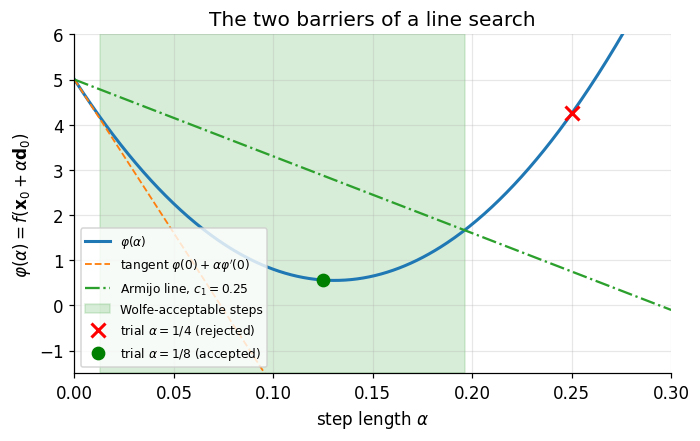

In [2]:
c1_fig, c2_fig = 0.25, 0.9
phi = lambda a: 260.0 * a**2 - 68.0 * a + 5.0          # (1-2a)^2 + 4(1-8a)^2, expanded
dphi = lambda a: 520.0 * a - 68.0
phi0, dphi0 = phi(0.0), dphi(0.0)

# Armijo holds for 260 a^2 <= (1-c1)*68*a  ->  a <= (1-c1)*68/260
a_armijo = (1.0 - c1_fig) * 68.0 / 260.0
# curvature holds for 520 a - 68 >= c2 * (-68)  ->  a >= (1-c2)*68/520
a_curv = (1.0 - c2_fig) * 68.0 / 520.0
print(f"Armijo holds on (0, {a_armijo:.6f}]")
print(f"curvature holds on [{a_curv:.6f}, inf)")
print(f"Wolfe-acceptable set = [{a_curv:.6f}, {a_armijo:.6f}]")

grid = np.linspace(0.0, 0.30, 400)
fig, ax = plt.subplots()
ax.plot(grid, phi(grid), lw=2, label=r"$\varphi(\alpha)$")
ax.plot(grid, phi0 + grid * dphi0, "--", lw=1.2, label=r"tangent $\varphi(0)+\alpha\varphi'(0)$")
ax.plot(grid, phi0 + c1_fig * grid * dphi0, "-.", lw=1.5,
        label=rf"Armijo line, $c_1={c1_fig}$")
ax.axvspan(a_curv, a_armijo, alpha=0.18, color="tab:green", label="Wolfe-acceptable steps")
ax.plot([0.25], [phi(0.25)], "rx", ms=9, mew=2, label=r"trial $\alpha=1/4$ (rejected)")
ax.plot([0.125], [phi(0.125)], "go", ms=8, label=r"trial $\alpha=1/8$ (accepted)")
ax.set_xlim(0, 0.30)
ax.set_ylim(-1.5, 6.0)
ax.set_xlabel(r"step length $\alpha$")
ax.set_ylabel(r"$\varphi(\alpha)=f(\mathbf{x}_0+\alpha\mathbf{d}_0)$")
ax.set_title("The two barriers of a line search")
ax.legend(fontsize=8, loc="lower left")
plt.show()

**Interpretation.** The Armijo line starts above the tangent and slopes down more gently, so it is
satisfied automatically for tiny $\alpha$ and cuts under the curve at $\alpha = 0.19615$; the
curvature condition switches on at $\alpha = 0.013077$, where $\varphi'$ has risen to
$c_2\varphi'(0)$. The Wolfe set is the interval between them — nonempty, as Theorem 4.2 promises,
and containing the backtracking output $\alpha = 1/8$ but not the rejected trial $\alpha = 1/4$.

## 3. Definitions

### Definition 3.1 (Descent direction)

A vector $\mathbf{d} \in \mathbb{R}^n$ is a *descent direction* for $f$ at $\mathbf{x}$ if
$\nabla f(\mathbf{x})^T \mathbf{d} \lt 0$.

### Definition 3.2 (Armijo sufficient-decrease condition)

Fix $c_1 \in (0, 1)$. A step $\alpha \gt 0$ satisfies the *Armijo condition* along the descent
direction $\mathbf{d}_k$ if

$$
f(\mathbf{x}_k + \alpha \mathbf{d}_k) \le f(\mathbf{x}_k) + c_1\, \alpha\, \nabla f(\mathbf{x}_k)^T \mathbf{d}_k
$$

Since $0 \lt c_1 \lt 1$ and the slope is negative, the right-hand side is a line lying above the
tangent at $\alpha = 0$ and below the horizontal: accepted steps must beat a fixed fraction of the
first-order predicted decrease.

### Definition 3.3 (Wolfe conditions)

Fix $0 \lt c_1 \lt c_2 \lt 1$. A step $\alpha$ satisfies the *(weak) Wolfe conditions* if it
satisfies Definition 3.2 and, in addition, the *curvature condition*

$$
\nabla f(\mathbf{x}_k + \alpha \mathbf{d}_k)^T \mathbf{d}_k \ge c_2\, \nabla f(\mathbf{x}_k)^T \mathbf{d}_k
$$

It satisfies the *strong Wolfe conditions* if the curvature condition is tightened to
$\lvert \nabla f(\mathbf{x}_k + \alpha \mathbf{d}_k)^T \mathbf{d}_k\rvert \le c_2\, \lvert \nabla f(\mathbf{x}_k)^T \mathbf{d}_k\rvert$.
Standard choices are $c_1 = 10^{-4}$, and $c_2 = 0.9$ for quasi-Newton directions or $c_2 = 0.1$ for
nonlinear conjugate gradient.

### Definition 3.4 (Backtracking line search)

Given an initial trial $\bar{\alpha} \gt 0$, a contraction factor $\rho \in (0,1)$ and
$c_1 \in (0,1)$, try $\alpha = \bar{\alpha},\ \rho\bar{\alpha},\ \rho^2\bar{\alpha}, \dots$ and accept
the first value satisfying Definition 3.2.

### Definition 3.5 (Newton direction and Newton decrement)

At a point where $\nabla^2 f(\mathbf{x}_k) \succ 0$, the *Newton direction* $\mathbf{p}_k$ is the
minimizer of the local quadratic model
$m_k(\mathbf{p}) = f(\mathbf{x}_k) + \nabla f(\mathbf{x}_k)^T\mathbf{p} + \tfrac{1}{2}\mathbf{p}^T \nabla^2 f(\mathbf{x}_k)\mathbf{p}$,
that is, the solution of

$$
\nabla^2 f(\mathbf{x}_k)\, \mathbf{p}_k = -\nabla f(\mathbf{x}_k)
$$

The *Newton decrement* is
$\lambda(\mathbf{x}_k) = \left(\nabla f(\mathbf{x}_k)^T [\nabla^2 f(\mathbf{x}_k)]^{-1} \nabla f(\mathbf{x}_k)\right)^{1/2}$,
so that $\lambda^2 = -\nabla f(\mathbf{x}_k)^T \mathbf{p}_k$ is the model's predicted decrease, doubled.

### Definition 3.6 (Secant pair, and the two secant equations)

With

$$
\mathbf{s}_k = \mathbf{x}_{k+1} - \mathbf{x}_k, \qquad \mathbf{y}_k = \nabla f(\mathbf{x}_{k+1}) - \nabla f(\mathbf{x}_k)
$$

a *Hessian approximation* $B_{k+1} \in \mathbb{R}^{n\times n}$ is required to satisfy the **direct
secant equation**

$$
B_{k+1}\, \mathbf{s}_k = \mathbf{y}_k
$$

and the corresponding *inverse-Hessian approximation* $H_{k+1} = B_{k+1}^{-1}$ is required to satisfy
the **inverse secant equation**

$$
H_{k+1}\, \mathbf{y}_k = \mathbf{s}_k
$$

The two are equivalent whenever $B_{k+1}$ is invertible, and every statement below says explicitly
which of the two it is about: $B$ always denotes an approximation of $\nabla^2 f$, and $H$ always
denotes an approximation of $[\nabla^2 f]^{-1}$. In one dimension the direct equation reads
$B_{+} = \left(f'(x_{k+1}) - f'(x_k)\right)/(x_{k+1}-x_k)$, the finite-difference approximation of
$f''$ — hence the name.

### Definition 3.7 (BFGS update)

Given $\mathbf{s}_k^T\mathbf{y}_k \gt 0$ and $\rho_k = 1/(\mathbf{y}_k^T\mathbf{s}_k)$, the *BFGS
update* of the inverse-Hessian approximation is

$$
H_{k+1} = \left(I - \rho_k\, \mathbf{s}_k \mathbf{y}_k^T\right) H_k \left(I - \rho_k\, \mathbf{y}_k \mathbf{s}_k^T\right) + \rho_k\, \mathbf{s}_k \mathbf{s}_k^T
$$

and the equivalent update of the direct approximation is
$B_{k+1} = B_k - \dfrac{B_k \mathbf{s}_k \mathbf{s}_k^T B_k}{\mathbf{s}_k^T B_k \mathbf{s}_k} + \dfrac{\mathbf{y}_k\mathbf{y}_k^T}{\mathbf{y}_k^T\mathbf{s}_k}$.

### Definition 3.8 (Weighted Frobenius norm)

For a symmetric positive definite $W$, set $\lVert A \rVert_W = \lVert W^{1/2} A W^{1/2} \rVert_F$,
where $W^{1/2}$ is the symmetric positive definite square root of $W$. This is a genuine norm on
$\mathbb{R}^{n\times n}$ because $A \mapsto W^{1/2}AW^{1/2}$ is a linear bijection.

### Definition 3.9 (Rates of convergence)

Let $e_k = \lVert \mathbf{x}_k - \mathbf{x}^{\star}\rVert \to 0$ with $e_k \gt 0$. The convergence is
*linear with rate $r \in (0,1)$* if $e_{k+1} \le r\,e_k$ for all large $k$; *superlinear* if
$e_{k+1}/e_k \to 0$; and *quadratic* if $e_{k+1} \le C e_k^2$ for a constant $C$ and all large $k$.

## 4. Main Results

### Theorem 4.1 (Existence of Armijo steps)

Let $f$ be continuously differentiable in a neighbourhood of $\mathbf{x}_k$, let $\mathbf{d}_k$ be a
descent direction (Definition 3.1), and let $c_1 \in (0,1)$. Then there is $\bar{\alpha}_{\ast} \gt 0$
such that every $\alpha \in (0, \bar{\alpha}_{\ast}]$ satisfies the Armijo condition, and backtracking
(Definition 3.4) terminates after finitely many contractions.

*Why each hypothesis is needed.* Differentiability supplies the first-order expansion whose remainder
is $o(\alpha)$, without which no interval can be identified; the descent hypothesis makes the
first-order term strictly negative, so it can dominate the remainder; and $c_1 \lt 1$ leaves a
strictly positive margin $(1-c_1)\lvert \nabla f_k^T\mathbf{d}_k\rvert$ for the remainder to fit
inside — at $c_1 = 1$ the margin vanishes and the conclusion is false for, e.g., $f(x) = x^2$ at
$x=1$.

### Theorem 4.2 (Existence of Wolfe steps)

Assume in addition that $\varphi(\alpha) = f(\mathbf{x}_k + \alpha\mathbf{d}_k)$ is bounded below on
$\alpha \gt 0$, and that $0 \lt c_1 \lt c_2 \lt 1$. Then the set of steps satisfying the Wolfe
conditions (Definition 3.3) contains a nonempty open interval, and every point of it satisfies the
strong Wolfe conditions as well.

*Why each hypothesis is needed.* Boundedness below forces the descending Armijo line to cross the
graph of $\varphi$, which is what produces the crossing point the mean value theorem is applied to;
without it, $\varphi(\alpha) = -\alpha$ satisfies Armijo for every $\alpha$ and no crossing exists.
The strict inequality $c_1 \lt c_2$ is what makes the slope $c_1\varphi'(0)$ produced at the crossing
already flatter than the threshold $c_2\varphi'(0)$; if $c_2 \le c_1$ the two requirements can be
incompatible.

### Theorem 4.3 (Zoutendijk)

Let $f$ be bounded below on $\mathbb{R}^n$ and continuously differentiable on an open set containing
the sublevel set $\{\mathbf{x} : f(\mathbf{x}) \le f(\mathbf{x}_0)\}$, with $\nabla f$ Lipschitz of
constant $L$ there. Let $\mathbf{x}_{k+1} = \mathbf{x}_k + \alpha_k\mathbf{d}_k$ where each
$\mathbf{d}_k$ is a descent direction and each $\alpha_k$ satisfies the Wolfe conditions. Then, with
$\cos\theta_k = -\nabla f(\mathbf{x}_k)^T\mathbf{d}_k / \left(\lVert \nabla f(\mathbf{x}_k)\rVert\, \lVert \mathbf{d}_k\rVert\right)$,

$$
\sum_{k=0}^{\infty} \cos^2\theta_k\, \lVert \nabla f(\mathbf{x}_k)\rVert^2 \lt \infty
$$

Consequently, if $\cos\theta_k \ge \delta \gt 0$ for all $k$, then $\lVert \nabla f(\mathbf{x}_k)\rVert \to 0$.

*Why each hypothesis is needed.* Boundedness below caps the total decrease, which is the finite budget
the series is compared against; Lipschitz continuity of $\nabla f$ caps how much the slope can rise per
unit step and therefore turns the curvature condition into a *lower* bound on $\alpha_k$; the Armijo
half of the Wolfe pair converts that lower bound into decrease. Drop the curvature condition and steps
may shrink so fast that the series diverges while the gradient does not vanish.

### Theorem 4.4 (Local quadratic convergence of Newton's method)

Let $f$ be twice continuously differentiable near $\mathbf{x}^{\star}$ with
$\nabla f(\mathbf{x}^{\star}) = \mathbf{0}$ and $\nabla^2 f(\mathbf{x}^{\star}) \succeq \mu I$ for some
$\mu \gt 0$, and let $\nabla^2 f$ be Lipschitz of constant $M$ in the operator norm on the ball
$\mathcal{B} = \{\mathbf{x} : \lVert \mathbf{x} - \mathbf{x}^{\star}\rVert \le \mu/(2M)\}$. Then for
every $\mathbf{x}_0 \in \mathcal{B}$ the pure Newton iterates stay in $\mathcal{B}$ and satisfy

$$
\lVert \mathbf{x}_{k+1} - \mathbf{x}^{\star}\rVert \le \frac{M}{\mu}\, \lVert \mathbf{x}_k - \mathbf{x}^{\star}\rVert^2
$$

*Why each hypothesis is needed.* Stationarity at $\mathbf{x}^{\star}$ is what lets the gradient be
written as an integral of Hessians against the error; the uniform lower bound $\mu$ keeps
$\nabla^2 f(\mathbf{x}_k)$ invertible with $\lVert [\nabla^2 f(\mathbf{x}_k)]^{-1}\rVert_{\mathrm{op}} \le 2/\mu$
throughout $\mathcal{B}$, and without it the Newton step is undefined or unbounded; the Lipschitz
constant $M$ is exactly what makes the Taylor remainder quadratic rather than merely $o(\lVert \mathbf{e}_k\rVert)$.
The radius $\mu/(2M)$ is not decoration: it is the largest radius on which the Weyl bound
$\lambda_{\min}(\nabla^2 f(\mathbf{x}_k)) \ge \mu - M\lVert \mathbf{e}_k\rVert$ still guarantees
$\nabla^2 f(\mathbf{x}_k) \succeq \tfrac{\mu}{2}I$, and it is also small enough to make the contraction
$\tfrac{M}{\mu}\lVert \mathbf{e}_k\rVert \le \tfrac12$ self-sustaining.

### Theorem 4.5 (Affine invariance of Newton's method)

Let $T \in \mathbb{R}^{n\times n}$ be invertible, $\mathbf{b} \in \mathbb{R}^n$, and
$\tilde{f}(\mathbf{y}) = f(T\mathbf{y} + \mathbf{b})$. If $\nabla^2 f$ is invertible at
$\mathbf{x}_k = T\mathbf{y}_k + \mathbf{b}$, then the Newton directions satisfy
$\tilde{\mathbf{p}}_k = T^{-1}\mathbf{p}_k$, hence $\mathbf{x}_{k+1} = T\mathbf{y}_{k+1} + \mathbf{b}$:
the two runs of pure Newton are the *same* sequence read in two coordinate systems.

*Why each hypothesis is needed.* Invertibility of $T$ is what makes $T^T \nabla^2 f\, T$ invertible and
lets the transposes cancel; without it the reparameterization loses information and no correspondence of
iterates can exist. Nothing else is assumed — in particular no convexity — because the statement is an
identity, not an estimate.

### Theorem 4.6 (BFGS is the unique least-change symmetric secant update)

Let $H_k$ be symmetric, let $\mathbf{s}_k^T\mathbf{y}_k \gt 0$, and let $W$ be any symmetric positive
definite matrix with $W\mathbf{s}_k = \mathbf{y}_k$. Then the constrained problem

$$
\min_{H}\ \lVert H - H_k \rVert_W \quad \text{subject to} \quad H = H^T,\ H\mathbf{y}_k = \mathbf{s}_k
$$

has a unique solution, and that solution is exactly the BFGS update of Definition 3.7. Exchanging the
roles of $\mathbf{s}_k$ and $\mathbf{y}_k$ — minimizing $\lVert B - B_k\rVert_W$ subject to $B = B^T$,
$B\mathbf{s}_k = \mathbf{y}_k$, with $W\mathbf{y}_k = \mathbf{s}_k$ — gives the DFP update instead.

*Why each hypothesis is needed.* Symmetry of $H_k$ is what makes the projection onto the symmetric
secant-consistent set well defined; $\mathbf{s}_k^T\mathbf{y}_k \gt 0$ is exactly the condition for a
symmetric positive definite $W$ with $W\mathbf{s}_k = \mathbf{y}_k$ to exist at all (it forces
$\mathbf{s}_k^T W \mathbf{s}_k = \mathbf{s}_k^T\mathbf{y}_k \gt 0$); and positive definiteness of $W$
is what makes $\lVert \cdot \rVert_W$ a norm, so that the minimizer is unique. Notably the answer does
*not* depend on which admissible $W$ is chosen.

### Theorem 4.7 (BFGS preserves positive definiteness)

If $H_k \succ 0$ and $\mathbf{s}_k^T\mathbf{y}_k \gt 0$, then the BFGS update $H_{k+1}$ of
Definition 3.7 satisfies $H_{k+1} \succ 0$. Moreover, if $\mathbf{d}_k$ is a descent direction and
$\alpha_k$ satisfies the Wolfe curvature condition, then $\mathbf{s}_k^T\mathbf{y}_k \gt 0$ holds
automatically.

*Why each hypothesis is needed.* $H_k \succ 0$ makes the first of the two terms in the quadratic form
strictly positive except on a one-dimensional exceptional set; $\mathbf{s}_k^T\mathbf{y}_k \gt 0$ makes
$\rho_k \gt 0$, so the rank-one term added back is positive semidefinite and strictly positive exactly
on that exceptional set. Drop the curvature hypothesis and the conclusion fails outright: the
counterexample in Section 7 produces an indefinite $H_{k+1}$ and an ascent direction from it.

### Theorem 4.8 (Dennis–Moré characterization; cited, not proved here)

Let $\mathbf{x}_k \to \mathbf{x}^{\star}$ with $\nabla^2 f(\mathbf{x}^{\star}) \succ 0$ and
$\nabla f(\mathbf{x}^{\star}) = \mathbf{0}$, and suppose the iteration is
$\mathbf{x}_{k+1} = \mathbf{x}_k + \mathbf{p}_k$ with $B_k\mathbf{p}_k = -\nabla f(\mathbf{x}_k)$ and
unit steps eventually accepted. Then the convergence is superlinear if and only if

$$
\lim_{k\to\infty} \frac{\left\lVert \left(B_k - \nabla^2 f(\mathbf{x}^{\star})\right)\mathbf{p}_k\right\rVert}{\lVert \mathbf{p}_k\rVert} = 0
$$

and BFGS with a Wolfe line search satisfies this limit on a strongly convex $C^2$ objective. Reference:
Nocedal & Wright, *Numerical Optimization*, 2nd ed., §3.3 Theorem 3.6 (Dennis–Moré) and §6.4
Theorem 6.6 (superlinear convergence of BFGS). The strongest special case this module proves in full
is Theorem 4.4: when $B_k = \nabla^2 f(\mathbf{x}_k)$ exactly, the Dennis–Moré ratio is $O(\lVert \mathbf{e}_k\rVert)$
and the rate improves from superlinear to quadratic.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Write $g = \nabla f(\mathbf{x}_k)^T \mathbf{d}_k \lt 0$ and $\varphi(\alpha) = f(\mathbf{x}_k + \alpha \mathbf{d}_k)$.

**Step 1 (expand).** Differentiability of $f$ gives $\varphi(\alpha) = \varphi(0) + \alpha g + o(\alpha)$
as $\alpha \downarrow 0$.

**Step 2 (rearrange the requirement).** The Armijo condition $\varphi(\alpha) \le \varphi(0) + c_1\alpha g$
is, after substituting Step 1 and cancelling $\varphi(0)$, equivalent to

$$
\alpha(1 - c_1)\, g + o(\alpha) \le 0
$$

**Step 3 (divide).** Dividing by $\alpha \gt 0$, the requirement reads
$(1-c_1)g + o(\alpha)/\alpha \le 0$. Because $(1-c_1)g \lt 0$ is a fixed strictly negative number and
$o(\alpha)/\alpha \to 0$, there is $\bar{\alpha}_{\ast} \gt 0$ with
$\lvert o(\alpha)/\alpha \rvert \le (1-c_1)\lvert g \rvert$ for all $\alpha \in (0, \bar{\alpha}_{\ast}]$,
and on that whole interval the requirement holds.

**Step 4 (backtracking halts).** The trials $\rho^j\bar{\alpha}$ decrease to $0$, so
$j \ge \log(\bar{\alpha}_{\ast}/\bar{\alpha})/\log\rho$ puts the trial inside $(0,\bar{\alpha}_{\ast}]$;
the loop therefore stops at some $j$ no larger than that, and the accepted step is at least
$\rho\,\bar{\alpha}_{\ast}$ (or $\bar{\alpha}$ itself, if the first trial passes).

$$
\boxed{\text{descent direction} + c_1 \in (0,1) \implies \text{Armijo holds on an interval } (0, \bar{\alpha}_{\ast}] \text{ and backtracking halts}}
$$

**Interpretation.** The boxed statement says the sufficient-decrease test is never vacuous: there is
always something to accept, so a backtracking loop is a terminating algorithm rather than a
potentially infinite search. The consequence is that the *only* way a backtracking line search can
fail in practice is by running out of floating-point resolution, which is why production codes cap the
number of contractions and report a failure rather than looping.

### Proof 5.2 (of Theorem 4.2)

Let $g = \nabla f(\mathbf{x}_k)^T\mathbf{d}_k \lt 0$ and define the Armijo gap
$\psi(\alpha) = \varphi(\alpha) - \varphi(0) - c_1\alpha g$.

**Step 1 (a first crossing exists).** $\psi(0) = 0$ and $\psi'(0) = (1-c_1)g \lt 0$, so $\psi(\alpha) \lt 0$
for all small $\alpha \gt 0$. The comparison line $\varphi(0) + c_1\alpha g$ tends to $-\infty$ while
$\varphi$ is bounded below, so $\psi(\alpha) \to +\infty$. By the intermediate value theorem applied to
the continuous $\psi$, the set $\{\alpha \gt 0: \psi(\alpha) = 0\}$ is nonempty; let $\alpha'$ be its
infimum, which is positive and satisfies $\psi(\alpha') = 0$ by continuity. By minimality, the Armijo
condition holds on all of $(0, \alpha']$.

**Step 2 (mean value theorem).** Applying the mean value theorem to $\varphi$ on $[0, \alpha']$ gives
some $\alpha'' \in (0, \alpha')$ with

$$
\varphi(\alpha') - \varphi(0) = \alpha'\, \varphi'(\alpha'')
$$

**Step 3 (read off the slope).** The left-hand side equals $c_1\alpha' g$ because $\psi(\alpha') = 0$.
Dividing by $\alpha' \gt 0$,

$$
\varphi'(\alpha'') = c_1 g \gt c_2 g
$$

the last inequality because $g \lt 0$ and $c_1 \lt c_2$. So the curvature condition holds strictly at
$\alpha''$, and since $\alpha'' \lt \alpha'$ the Armijo condition holds there too.

**Step 4 (strong Wolfe, and an interval).** Also
$\lvert \varphi'(\alpha'')\rvert = c_1\lvert g\rvert \lt c_2 \lvert g \rvert$, so the strong form holds.
All the inequalities in Steps 1–3 are strict at $\alpha''$ and $\varphi, \varphi'$ are continuous, so an
open neighbourhood of $\alpha''$ satisfies them as well.

$$
\boxed{0 \lt c_1 \lt c_2 \lt 1 \text{ and } \varphi \text{ bounded below} \implies \text{the strong Wolfe set contains an open interval}}
$$

**Interpretation.** The boxed statement means a Wolfe line search is a well-posed search: it is
looking for a set that provably has interior, so a bisection-style algorithm on $\alpha$ cannot
converge to an empty target. The consequence is architectural — it is why every serious solver ships a
Wolfe (not merely Armijo) line search when it intends to feed the accepted step to a quasi-Newton
update, which needs the curvature half.

### Proof 5.3 (of Theorem 4.3)

**Step 1 (the curvature condition bounds the step from below).** Subtract
$g_k = \nabla f(\mathbf{x}_k)^T\mathbf{d}_k$ from both sides of the curvature condition:

$$
\left(\nabla f(\mathbf{x}_{k+1}) - \nabla f(\mathbf{x}_k)\right)^T \mathbf{d}_k \ge (c_2 - 1)\, g_k \gt 0
$$

By Cauchy–Schwarz and the Lipschitz property, the left side is at most
$L\lVert \mathbf{x}_{k+1}-\mathbf{x}_k\rVert\,\lVert \mathbf{d}_k\rVert = L\alpha_k\lVert \mathbf{d}_k\rVert^2$.
Therefore

$$
\alpha_k \ge \frac{(1 - c_2)\, \lvert g_k\rvert}{L\, \lVert \mathbf{d}_k\rVert^2}
$$

**Step 2 (Armijo converts the step bound into decrease).** Armijo reads
$f(\mathbf{x}_{k+1}) \le f(\mathbf{x}_k) - c_1\alpha_k\lvert g_k\rvert$. Inserting Step 1,

$$
f(\mathbf{x}_{k+1}) \le f(\mathbf{x}_k) - \frac{c_1(1-c_2)}{L}\cdot\frac{g_k^2}{\lVert \mathbf{d}_k\rVert^2} = f(\mathbf{x}_k) - c\, \cos^2\theta_k\, \lVert \nabla f(\mathbf{x}_k)\rVert^2
$$

with $c = c_1(1-c_2)/L \gt 0$, using $g_k^2 / \lVert \mathbf{d}_k\rVert^2 = \cos^2\theta_k\,\lVert \nabla f(\mathbf{x}_k)\rVert^2$.

**Step 3 (telescope).** Summing Step 2 for $k = 0,\dots,K$ and using $f(\mathbf{x}_{K+1}) \ge f_{\inf}$,

$$
c \sum_{k=0}^{K} \cos^2\theta_k\, \lVert \nabla f(\mathbf{x}_k)\rVert^2 \le f(\mathbf{x}_0) - f_{\inf} \lt \infty
$$

The partial sums are bounded and the terms are nonnegative, so the series converges as $K \to \infty$.

**Step 4 (the corollary).** A convergent series has terms tending to $0$. If $\cos\theta_k \ge \delta \gt 0$
then $\lVert \nabla f(\mathbf{x}_k)\rVert^2 \le \delta^{-2}\cos^2\theta_k \lVert \nabla f(\mathbf{x}_k)\rVert^2 \to 0$.

$$
\boxed{\sum_k \cos^2\theta_k\, \lVert \nabla f(\mathbf{x}_k)\rVert^2 \le \frac{L\left(f(\mathbf{x}_0) - f_{\inf}\right)}{c_1(1-c_2)}}
$$

**Interpretation.** The boxed inequality prices global convergence explicitly: the total "angle-weighted
gradient energy" an algorithm may ever spend is at most the initial suboptimality divided by
$c_1(1-c_2)/L$. The consequence is a clean division of labour — the line search supplies summability
once and for all, and any direction rule whatsoever becomes globally convergent as soon as it can
certify one angle bound $\cos\theta_k \ge \delta$. For steepest descent $\cos\theta_k \equiv 1$; for a
quasi-Newton direction $\mathbf{d}_k = -H_k\nabla f_k$ with
$\kappa(H_k) \le \bar{\kappa}$ one gets $\cos\theta_k \ge 1/\bar{\kappa}$.

### Proof 5.4 (of Theorem 4.4)

Write $\mathbf{e}_k = \mathbf{x}_k - \mathbf{x}^{\star}$ and $H_k = \nabla^2 f(\mathbf{x}_k)$ (an
abbreviation local to this proof). Assume inductively $\mathbf{x}_k \in \mathcal{B}$, i.e.
$\lVert \mathbf{e}_k\rVert \le \mu/(2M)$.

**Step 1 (the error recursion).** The pure Newton step
$\mathbf{x}_{k+1} = \mathbf{x}_k - H_k^{-1}\nabla f(\mathbf{x}_k)$ gives

$$
\mathbf{e}_{k+1} = \mathbf{e}_k - H_k^{-1}\nabla f(\mathbf{x}_k) = H_k^{-1}\left(H_k\mathbf{e}_k - \nabla f(\mathbf{x}_k)\right)
$$

**Step 2 (Taylor with integral remainder).** Since $\nabla f(\mathbf{x}^{\star}) = \mathbf{0}$, the
fundamental theorem of calculus applied to $t \mapsto \nabla f(\mathbf{x}^{\star} + t\mathbf{e}_k)$ gives

$$
\nabla f(\mathbf{x}_k) = \int_0^1 \nabla^2 f(\mathbf{x}^{\star} + t\, \mathbf{e}_k)\, \mathbf{e}_k \, dt
$$

and therefore, writing $H_k \mathbf{e}_k = \int_0^1 H_k \mathbf{e}_k\, dt$,

$$
H_k \mathbf{e}_k - \nabla f(\mathbf{x}_k) = \int_0^1 \left[\nabla^2 f(\mathbf{x}_k) - \nabla^2 f(\mathbf{x}^{\star} + t\, \mathbf{e}_k)\right] \mathbf{e}_k \, dt
$$

**Step 3 (Lipschitz bound on the integrand).** The two Hessian arguments differ by
$\mathbf{x}_k - (\mathbf{x}^{\star} + t\mathbf{e}_k) = (1-t)\mathbf{e}_k$, and both lie in $\mathcal{B}$
because $\mathcal{B}$ is convex and contains $\mathbf{x}_k$ and $\mathbf{x}^{\star}$. Hence

$$
\lVert H_k \mathbf{e}_k - \nabla f(\mathbf{x}_k)\rVert \le \int_0^1 M(1-t)\, \lVert \mathbf{e}_k\rVert^2 \, dt = \frac{M}{2}\, \lVert \mathbf{e}_k\rVert^2
$$

**Step 4 (bound the inverse — this is where the radius is used).** By Weyl's inequality applied to the
symmetric matrices $\nabla^2 f(\mathbf{x}_k)$ and $\nabla^2 f(\mathbf{x}^{\star})$,

$$
\lambda_{\min}\!\left(\nabla^2 f(\mathbf{x}_k)\right) \ge \lambda_{\min}\!\left(\nabla^2 f(\mathbf{x}^{\star})\right) - \lVert \nabla^2 f(\mathbf{x}_k) - \nabla^2 f(\mathbf{x}^{\star})\rVert_{\mathrm{op}} \ge \mu - M\lVert \mathbf{e}_k\rVert \ge \mu - \frac{\mu}{2} = \frac{\mu}{2}
$$

using $\lVert \mathbf{e}_k \rVert \le \mu/(2M)$. So $H_k \succeq \tfrac{\mu}{2}I$, hence $H_k$ is invertible
with $\lVert H_k^{-1}\rVert_{\mathrm{op}} \le 2/\mu$.

**Step 5 (combine).** Steps 1, 3 and 4 give

$$
\lVert \mathbf{e}_{k+1}\rVert \le \lVert H_k^{-1}\rVert_{\mathrm{op}}\, \lVert H_k\mathbf{e}_k - \nabla f(\mathbf{x}_k)\rVert \le \frac{2}{\mu}\cdot\frac{M}{2}\, \lVert \mathbf{e}_k\rVert^2 = \frac{M}{\mu}\, \lVert \mathbf{e}_k\rVert^2
$$

**Step 6 (the induction closes).** Since $\lVert \mathbf{e}_k\rVert \le \mu/(2M)$, Step 5 gives
$\lVert \mathbf{e}_{k+1}\rVert \le \frac{M}{\mu}\cdot\frac{\mu}{2M}\lVert \mathbf{e}_k\rVert = \tfrac12 \lVert \mathbf{e}_k\rVert \le \mu/(2M)$,
so $\mathbf{x}_{k+1} \in \mathcal{B}$ and the argument repeats. Writing
$t_k = \frac{M}{\mu}\lVert \mathbf{e}_k\rVert \le \tfrac12$, Step 5 says $t_{k+1} \le t_k^2$, hence
$t_k \le 2^{-2^k}$.

$$
\boxed{\lVert \mathbf{x}_{k+1} - \mathbf{x}^{\star}\rVert \le \frac{M}{\mu}\, \lVert \mathbf{x}_k - \mathbf{x}^{\star}\rVert^2 \quad \text{for } \lVert \mathbf{x}_0 - \mathbf{x}^{\star}\rVert \le \frac{\mu}{2M}}
$$

**Interpretation.** The constant is $M/\mu$ — the Hessian's Lipschitz constant divided by its smallest
eigenvalue at the solution — and not $M/(2\mu)$: the factor $\tfrac12$ gained from the integral
$\int_0^1(1-t)\,dt$ is spent again on the factor $2$ in $\lVert H_k^{-1}\rVert_{\mathrm{op}} \le 2/\mu$,
which is the price of only knowing the curvature floor $\mu$ at $\mathbf{x}^{\star}$ rather than at
$\mathbf{x}_k$. The consequence is quantitative: $t_k \le 2^{-2^k}$ means correct digits double per
iteration once inside the ball, so the last three Newton iterations of any run are essentially free —
and the entire practical difficulty is *reaching* the ball, which is the job of the line search.

### Proof 5.5 (of Theorem 4.5)

Let $\tilde{f}(\mathbf{y}) = f(T\mathbf{y} + \mathbf{b})$ and $\mathbf{x} = T\mathbf{y} + \mathbf{b}$.

**Step 1 (chain rule).** For a column-gradient convention,

$$
\nabla \tilde{f}(\mathbf{y}) = T^T \nabla f(\mathbf{x}), \qquad \nabla^2 \tilde{f}(\mathbf{y}) = T^T \nabla^2 f(\mathbf{x})\, T
$$

**Step 2 (invert and cancel).** Because $T$ and $\nabla^2 f(\mathbf{x})$ are invertible, so is
$T^T \nabla^2 f(\mathbf{x}) T$, and

$$
\tilde{\mathbf{p}} = -\left[T^T \nabla^2 f(\mathbf{x})\, T\right]^{-1} T^T \nabla f(\mathbf{x}) = -T^{-1}\left[\nabla^2 f(\mathbf{x})\right]^{-1} T^{-T} T^T \nabla f(\mathbf{x}) = T^{-1}\mathbf{p}
$$

**Step 3 (iterates correspond).** If $\mathbf{x}_k = T\mathbf{y}_k + \mathbf{b}$ then
$T(\mathbf{y}_k + \tilde{\mathbf{p}}) + \mathbf{b} = T\mathbf{y}_k + \mathbf{b} + T T^{-1}\mathbf{p} = \mathbf{x}_k + \mathbf{p}$,
which is $\mathbf{x}_{k+1}$; by induction the whole trajectories correspond.

**Step 4 (contrast).** The steepest-descent direction transforms as
$-\nabla\tilde{f}(\mathbf{y}) = -T^T\nabla f(\mathbf{x})$, which equals $T^{-1}(-\nabla f(\mathbf{x}))$
for all gradients only if $T^T = T^{-1}$, i.e. only for orthogonal $T$.

$$
\boxed{\mathbf{x} = T\mathbf{y} + \mathbf{b},\ T \text{ invertible} \implies \text{pure Newton produces the same trajectory in either coordinate system}}
$$

**Interpretation.** The boxed identity says Newton has no units: rescaling a feature by $10^3$, or
whitening the variables, changes neither the iterates nor the number of iterations. The consequence is
that Newton's convergence theory cannot legitimately depend on the condition number $\kappa$ — which is
a coordinate-dependent quantity — and indeed the constant in Theorem 4.4, $M/\mu$, is only *apparently*
coordinate-dependent: it is the affine-invariant self-concordance ratio in disguise, which is why Boyd
and Vandenberghe restate the whole analysis in terms of the Newton decrement of Definition 3.5.

### Proof 5.6 (of Theorem 4.6)

Drop the index $k$ and write $\mathbf{s}, \mathbf{y}, H_0 := H_k$. Let $W \succ 0$ with
$W\mathbf{s} = \mathbf{y}$, and let $W^{1/2}$ be its symmetric positive definite square root.

**Step 1 (whiten).** Substitute $\widehat{H} = W^{1/2} H W^{1/2}$, $\widehat{H}_0 = W^{1/2}H_0W^{1/2}$,
$\hat{\mathbf{s}} = W^{1/2}\mathbf{s}$, $\hat{\mathbf{y}} = W^{-1/2}\mathbf{y}$. Because
$W\mathbf{s} = \mathbf{y}$ we get $\hat{\mathbf{y}} = W^{-1/2}W\mathbf{s} = W^{1/2}\mathbf{s} = \hat{\mathbf{s}}$:
in the whitened coordinates the two vectors coincide. The map $H \mapsto \widehat{H}$ is a linear
bijection preserving symmetry, it turns the constraint $H\mathbf{y} = \mathbf{s}$ into
$\widehat{H}\hat{\mathbf{s}} = W^{1/2}H\mathbf{y} = W^{1/2}\mathbf{s} = \hat{\mathbf{s}}$, and by
Definition 3.8 it turns the objective into $\lVert \widehat{H} - \widehat{H}_0\rVert_F$. So the problem
is now: minimize $\lVert \widehat{H} - \widehat{H}_0\rVert_F$ over symmetric $\widehat{H}$ fixing the
vector $\hat{\mathbf{s}}$.

**Step 2 (block-diagonalize).** Note $\hat{\mathbf{s}} \ne \mathbf{0}$ because
$\lVert \hat{\mathbf{s}}\rVert^2 = \mathbf{s}^TW\mathbf{s} = \mathbf{s}^T\mathbf{y} \gt 0$. Put
$\mathbf{u} = \hat{\mathbf{s}}/\lVert \hat{\mathbf{s}}\rVert$ and $P = I - \mathbf{u}\mathbf{u}^T$, the
orthogonal projector onto $\mathbf{u}^{\perp}$. A symmetric $\widehat{H}$ satisfies
$\widehat{H}\mathbf{u} = \mathbf{u}$ if and only if, in the splitting
$\mathbb{R}^n = \operatorname{span}(\mathbf{u}) \oplus \mathbf{u}^{\perp}$, its $(\mathbf{u},\mathbf{u})$
entry is $1$ and its off-diagonal block $P\widehat{H}\mathbf{u}$ vanishes; symmetry then kills the
transposed block too. Hence the feasible set is exactly

$$
\left\{\widehat{H} = \mathbf{u}\mathbf{u}^T + PCP \ : \ C = C^T\right\}
$$

**Step 3 (separate the objective).** Decompose $\widehat{H}_0$ in the same splitting,
$a = \mathbf{u}^T\widehat{H}_0\mathbf{u}$ and $\mathbf{b} = P\widehat{H}_0\mathbf{u}$. Since the four
blocks are mutually orthogonal in the Frobenius inner product,

$$
\lVert \widehat{H} - \widehat{H}_0 \rVert_F^2 = (1-a)^2 + 2\lVert \mathbf{b}\rVert^2 + \lVert PCP - P\widehat{H}_0P\rVert_F^2
$$

Only the last term depends on $C$, and it is minimized — uniquely, being a squared norm of an affine
function of $PCP$ — at $PCP = P\widehat{H}_0P$. Therefore

$$
\widehat{H}_{+} = \mathbf{u}\mathbf{u}^T + P\widehat{H}_0P = \left(I - \mathbf{u}\mathbf{u}^T\right)\widehat{H}_0\left(I - \mathbf{u}\mathbf{u}^T\right) + \mathbf{u}\mathbf{u}^T
$$

**Step 4 (unwhiten).** Using $\lVert \hat{\mathbf{s}}\rVert^2 = \mathbf{s}^T\mathbf{y}$ and
$\rho = 1/(\mathbf{y}^T\mathbf{s})$, we have
$\mathbf{u}\mathbf{u}^T = \rho\, W^{1/2}\mathbf{s}\mathbf{s}^T W^{1/2}$, hence

$$
W^{-1/2}\left(I - \mathbf{u}\mathbf{u}^T\right)W^{1/2} = I - \rho\, \mathbf{s}\,\mathbf{s}^TW = I - \rho\, \mathbf{s}\,(W\mathbf{s})^T = I - \rho\, \mathbf{s}\mathbf{y}^T
$$

$$
W^{1/2}\left(I - \mathbf{u}\mathbf{u}^T\right)W^{-1/2} = I - \rho\, (W\mathbf{s})\,\mathbf{s}^T = I - \rho\, \mathbf{y}\mathbf{s}^T, \qquad W^{-1/2}\mathbf{u}\mathbf{u}^TW^{-1/2} = \rho\, \mathbf{s}\mathbf{s}^T
$$

Conjugating the Step 3 formula by $W^{-1/2}$ and inserting $W^{1/2}W^{-1/2} = I$ between the factors,

$$
H_{+} = W^{-1/2}\widehat{H}_{+}W^{-1/2} = \left(I - \rho\, \mathbf{s}\mathbf{y}^T\right)H_0\left(I - \rho\, \mathbf{y}\mathbf{s}^T\right) + \rho\, \mathbf{s}\mathbf{s}^T
$$

which is Definition 3.7. Uniqueness is inherited from Step 3, and the answer visibly does not depend
on $W$.

$$
\boxed{H_{k+1} = \underset{H = H^T,\ H\mathbf{y}_k = \mathbf{s}_k}{\operatorname{argmin}}\ \lVert H - H_k\rVert_W \quad \text{for every } W \succ 0 \text{ with } W\mathbf{s}_k = \mathbf{y}_k}
$$

**Interpretation.** BFGS is not a lucky algebraic guess: it is an *orthogonal projection*. The secant
equation is one $n$-dimensional linear constraint on a symmetric matrix, leaving
$n(n-1)/2$ degrees of freedom undetermined, and BFGS resolves them by changing as little as possible —
in the one family of norms in which the answer is independent of the arbitrary weight. The consequence
is both practical and conceptual: practically, the update inherits every property of $H_k$ that survives
projection (Theorem 4.7 is the positive-definiteness instance); conceptually, DFP is the same projection
performed on $B$ instead of $H$, which is why the two updates are dual rather than rival heuristics.

### Proof 5.7 (of Theorem 4.7)

Drop the index $k$ and set $\rho = 1/(\mathbf{y}^T\mathbf{s}) \gt 0$.

**Step 1 (complete the square).** For any $\mathbf{z} \ne \mathbf{0}$, put
$\mathbf{w} = \left(I - \rho\, \mathbf{y}\mathbf{s}^T\right)\mathbf{z} = \mathbf{z} - \rho(\mathbf{s}^T\mathbf{z})\mathbf{y}$.
Reading Definition 3.7 as $H_{+} = V^T H V + \rho\mathbf{s}\mathbf{s}^T$ with
$V = I - \rho\,\mathbf{y}\mathbf{s}^T$,

$$
\mathbf{z}^T H_{+} \mathbf{z} = \mathbf{w}^T H \mathbf{w} + \rho\, \left(\mathbf{s}^T\mathbf{z}\right)^2
$$

**Step 2 (both terms are nonnegative).** $\mathbf{w}^T H \mathbf{w} \ge 0$ because $H \succ 0$, and
$\rho(\mathbf{s}^T\mathbf{z})^2 \ge 0$ because $\rho \gt 0$.

**Step 3 (rule out equality).** Suppose $\mathbf{z}^TH_{+}\mathbf{z} = 0$. Then both terms vanish. The
second gives $\mathbf{s}^T\mathbf{z} = 0$, whence $\mathbf{w} = \mathbf{z}$; the first then reads
$\mathbf{z}^TH\mathbf{z} = 0$, and $H \succ 0$ forces $\mathbf{z} = \mathbf{0}$, contradicting
$\mathbf{z} \ne \mathbf{0}$. Hence $\mathbf{z}^TH_{+}\mathbf{z} \gt 0$ for every $\mathbf{z} \ne \mathbf{0}$.

**Step 4 (Wolfe supplies the curvature hypothesis).** With $\mathbf{s}_k = \alpha_k\mathbf{d}_k$ and
$\alpha_k \gt 0$, subtract $\nabla f(\mathbf{x}_k)^T\mathbf{d}_k$ from the curvature condition of
Definition 3.3:

$$
\mathbf{y}_k^T\mathbf{d}_k \ge (c_2 - 1)\, \nabla f(\mathbf{x}_k)^T\mathbf{d}_k \gt 0
$$

strictly, because $c_2 \lt 1$ and $\nabla f(\mathbf{x}_k)^T\mathbf{d}_k \lt 0$. Multiplying by
$\alpha_k \gt 0$ gives $\mathbf{y}_k^T\mathbf{s}_k \gt 0$.

$$
\boxed{H_k \succ 0 \ \text{and}\ \mathbf{s}_k^T\mathbf{y}_k \gt 0 \implies H_{k+1} \succ 0, \ \text{and the Wolfe curvature condition implies } \mathbf{s}_k^T\mathbf{y}_k \gt 0}
$$

**Interpretation.** The boxed implication is what makes quasi-Newton directions self-certifying:
$H_k \succ 0$ gives $\nabla f_k^T\mathbf{d}_k = -\nabla f_k^T H_k \nabla f_k \lt 0$, so every BFGS
direction is a descent direction, so the line search of Theorem 4.2 applies, so the next update again
has $\mathbf{s}^T\mathbf{y} \gt 0$ — an induction that never needs a single second derivative. The
consequence is that the line search and the update are not independent modules: the curvature condition
exists in large part to protect the positive definiteness of $H$, which is exactly why a solver that
downgrades to a pure Armijo backtracking line search must also add a skip-or-damp safeguard on the BFGS
update.

## 6. Worked Examples

Each example uses deliberately small objects, is computed by hand first, and is then recomputed in
code with an assertion that the two agree.

### Example 6.1 (of Theorems 4.1 and 4.2) — backtracking on a $2\times 2$ quadratic

Take $f(x,y) = x^2 + 4y^2$, $\mathbf{x}_0 = (1,1)$, $c_1 = 1/4$, $c_2 = 0.9$, $\rho = 1/2$,
$\bar{\alpha} = 1$.

**Data.** $\nabla f = (2x, 8y)$, so $\nabla f(\mathbf{x}_0) = (2,8)$, $\mathbf{d}_0 = -(2,8)$,
$f(\mathbf{x}_0) = 5$ and $\varphi'(0) = \nabla f_0^T\mathbf{d}_0 = -(4+64) = -68$. Expanding,

$$
\varphi(\alpha) = (1-2\alpha)^2 + 4(1-8\alpha)^2 = 260\alpha^2 - 68\alpha + 5
$$

**The trials.** The Armijo bound is $5 - \tfrac{1}{4}(68)\alpha = 5 - 17\alpha$.

| $\alpha$ | $\varphi(\alpha)$ | Armijo bound $5-17\alpha$ | verdict |
|---|---|---|---|
| $1$ | $260-68+5 = 197$ | $-12$ | reject |
| $1/2$ | $65-34+5 = 36$ | $-3.5$ | reject |
| $1/4$ | $16.25-17+5 = 4.25$ | $0.75$ | reject |
| $1/8$ | $4.0625-8.5+5 = 0.5625$ | $2.875$ | **accept** |

**The accepted step.** $\alpha_0 = 1/8$, $\mathbf{x}_1 = (1,1) + \tfrac18(-2,-8) = (0.75, 0)$,
$f(\mathbf{x}_1) = 0.5625$.

**Curvature check.** $\nabla f(\mathbf{x}_1) = (1.5, 0)$, so
$\nabla f(\mathbf{x}_1)^T\mathbf{d}_0 = -3 \ge c_2\varphi'(0) = -61.2$: the accepted step also satisfies
the (strong) Wolfe curvature condition, so a Wolfe line search would have accepted it too.

**Against the theory.** Here $L = \lambda_{\max}(\nabla^2 f) = 8$, and every
$\alpha \le 2(1-c_1)\lvert \varphi'(0)\rvert / (L\lVert \mathbf{d}_0\rVert^2) = 2(0.75)(68)/(8\cdot 68) = 0.1875$
passes Armijo. Backtracking therefore had to stop no later than the first trial below $0.1875$, and it
returned $0.125 \ge \rho \cdot 0.1875 = 0.09375$.

The cell below recomputes the whole table of Example 6.1 and asserts every entry.

In [3]:
f_q  = lambda v: v[0]**2 + 4.0*v[1]**2
g_q  = lambda v: np.array([2.0*v[0], 8.0*v[1]])
x0 = np.array([1.0, 1.0])
d0 = -g_q(x0)
c1, c2, rho_bt = 0.25, 0.9, 0.5
slope0 = g_q(x0) @ d0
print(f"f(x0) = {f_q(x0)}, slope phi'(0) = {slope0}")

alpha, trials = 1.0, []
while True:
    ok = f_q(x0 + alpha*d0) <= f_q(x0) + c1*alpha*slope0
    trials.append((alpha, f_q(x0 + alpha*d0), f_q(x0) + c1*alpha*slope0, ok))
    if ok:
        break
    alpha *= rho_bt
for a, ph, bd, ok in trials:
    print(f"  alpha={a:<7.4f} phi={ph:<10.6f} bound={bd:<10.6f} {'accept' if ok else 'reject'}")

x1 = x0 + alpha*d0
L_q = 8.0
a_safe = 2*(1-c1)*abs(slope0)/(L_q*(d0 @ d0))
print(f"accepted alpha = {alpha},  x1 = {x1},  f(x1) = {f_q(x1)}")
print(f"curvature: grad(x1).d0 = {g_q(x1) @ d0:.4f}  >=  c2*slope0 = {c2*slope0:.4f}")
print(f"alpha_safe = {a_safe},  rho*alpha_safe = {rho_bt*a_safe}")

assert alpha == 0.125
assert np.allclose(x1, [0.75, 0.0]) and np.isclose(f_q(x1), 0.5625)
assert [round(t[1], 6) for t in trials] == [197.0, 36.0, 4.25, 0.5625]
assert g_q(x1) @ d0 >= c2*slope0
assert alpha >= rho_bt*a_safe and alpha <= a_safe

f(x0) = 5.0, slope phi'(0) = -68.0
  alpha=1.0000  phi=197.000000 bound=-12.000000 reject
  alpha=0.5000  phi=36.000000  bound=-3.500000  reject
  alpha=0.2500  phi=4.250000   bound=0.750000   reject
  alpha=0.1250  phi=0.562500   bound=2.875000   accept
accepted alpha = 0.125,  x1 = [0.75 0.  ],  f(x1) = 0.5625
curvature: grad(x1).d0 = -3.0000  >=  c2*slope0 = -61.2000
alpha_safe = 0.1875,  rho*alpha_safe = 0.09375


**Interpretation.** The printed trial values reproduce the hand table exactly, the accepted step
$1/8$ lies inside the guaranteed window $[\rho\,\alpha_{\text{safe}}, \alpha_{\text{safe}}] = [0.09375, 0.1875]$
predicted by Proof 5.1, and it clears the curvature threshold by a wide margin — so this single step is
simultaneously an instance of Theorem 4.1 and of Theorem 4.2.

### Example 6.2 (of Theorem 4.3) — the Zoutendijk budget on the same quadratic

Keep $f(x,y) = x^2+4y^2$ and run steepest descent with an *exact* line search from
$\mathbf{x}_0 = (1,1)$. Exact minimization gives $\varphi'(\alpha) = 0$, so the curvature condition holds
for any $c_2$; and for a quadratic the exact step yields decrease exactly half the tangent prediction,
so Armijo holds for any $c_1 \le 1/2$. Take $c_1 = 1/4$, $c_2 = 0.1$; steepest descent has
$\cos\theta_k \equiv 1$.

**First step by hand.** $\varphi(\alpha) = 260\alpha^2 - 68\alpha + 5$ from Example 6.1, so
$\varphi'(\alpha) = 520\alpha - 68 = 0$ at

$$
\alpha_0 = \frac{68}{520} = \frac{17}{130}, \qquad \mathbf{x}_1 = \left(\frac{48}{65}, -\frac{3}{65}\right), \qquad f(\mathbf{x}_1) = \frac{36}{65} \approx 0.553846
$$

**Second term of the series.** $\nabla f(\mathbf{x}_1) = (96/65, -24/65)$, so
$\lVert \nabla f(\mathbf{x}_1)\rVert^2 = 9792/4225 \approx 2.3176$, and
$\lVert \nabla f(\mathbf{x}_0)\rVert^2 = 68$.

**The budget.** Proof 5.3 caps the whole series by
$\left(f(\mathbf{x}_0) - f_{\inf}\right)L / \left(c_1(1-c_2)\right) = 5 \cdot 8 / (0.25 \cdot 0.9) = 177.78$.
The first two terms already contribute $68 + 2.3176 = 70.32$, and the remaining terms decay
geometrically with ratio $f_{k+1}/f_k$.

The cell below runs the iteration to convergence, sums the Zoutendijk series and asserts it stays
under the budget.

In [4]:
Q_q = np.diag([2.0, 8.0])           # Hessian of f(x,y) = x^2 + 4y^2
x = np.array([1.0, 1.0])
c1_z, c2_z = 0.25, 0.1
series, f_hist = 0.0, [f_q(x)]
for k in range(200):
    gk = g_q(x)
    series += (gk @ gk)             # cos(theta_k) = 1 for steepest descent
    d = -gk
    a = -(gk @ d) / (d @ Q_q @ d)   # exact line search on a quadratic
    if k < 2:
        print(f"k={k}: x={x}, f={f_q(x):.6f}, |grad|^2={gk @ gk:.6f}, alpha={a:.6f}")
    x = x + a*d
    f_hist.append(f_q(x))
    if np.linalg.norm(g_q(x)) < 1e-14:
        break

budget = (f_hist[0] - 0.0) * 8.0 / (c1_z * (1 - c2_z))
print(f"Zoutendijk series  sum cos^2(theta_k)|grad f_k|^2 = {series:.6f}")
print(f"Proof 5.3 budget   L(f0 - f_inf)/(c1(1-c2))       = {budget:.6f}")
print(f"final |grad f| = {np.linalg.norm(g_q(x)):.3e}")
assert np.isclose(17/130, 68/520)
assert series < budget
assert np.linalg.norm(g_q(x)) < 1e-12

k=0: x=[1. 1.], f=5.000000, |grad|^2=68.000000, alpha=0.130769
k=1: x=[ 0.7385 -0.0462], f=0.553846, |grad|^2=2.317633, alpha=0.425000
Zoutendijk series  sum cos^2(theta_k)|grad f_k|^2 = 71.191136
Proof 5.3 budget   L(f0 - f_inf)/(c1(1-c2))       = 177.777778
final |grad f| = 7.060e-15


**Interpretation.** The first two printed terms, $68$ and $2.3176$, match the hand computation, and
the fully summed series $71.19$ sits comfortably under the budget $177.78$ that Proof 5.3 allows —
finite, as Theorem 4.3 claims. Since $\cos\theta_k \equiv 1$ here, convergence of the series is
literally the statement $\lVert \nabla f(\mathbf{x}_k)\rVert \to 0$, confirmed by the final gradient
norm.

### Example 6.3 (of Theorem 4.4) — Newton's digits double on $f(x) = e^{x} - x$

Take $f(x) = e^x - x$, so $f'(x) = e^x - 1$, $f''(x) = e^x$, and $x^{\star} = 0$ with $f''(0) = 1$.
Restrict attention to $I = [-\tfrac12, \tfrac12]$, on which $\lvert f'''\rvert = e^x \le e^{1/2}$, so
$M = e^{1/2} \approx 1.6487$ is a valid Hessian-Lipschitz constant and $\mu = f''(0) = 1$. Theorem 4.4
guarantees the quadratic bound on the ball $\lvert x_0\rvert \le \mu/(2M) = e^{-1/2}/2 \approx 0.30327$.

**The iteration in closed form.**

$$
x_{k+1} = x_k - \frac{e^{x_k}-1}{e^{x_k}} = x_k - 1 + e^{-x_k}
$$

**By hand from $x_0 = 0.3$** (inside the guaranteed ball): $e^{-0.3} = 0.7408182$, so

$$
x_1 = 0.3 - 1 + 0.7408182 = 0.0408182
$$

and the observed ratio is $\lvert x_1\rvert / x_0^2 = 0.0408182/0.09 = 0.45354$, comfortably below the
predicted bound $M/\mu = 1.6487$.

**The asymptotic constant.** Expanding $x - 1 + e^{-x} = \tfrac{x^2}{2} - \tfrac{x^3}{6} + \cdots$, the
ratio $\lvert x_{k+1}\rvert/x_k^2$ must tend to $\tfrac12 = f'''(0)/(2f''(0))$ — a number strictly
inside the guaranteed bound $M/\mu$.

The cell below iterates, prints the observed contraction ratios against both the guaranteed bound
$M/\mu$ and the asymptotic constant $1/2$, and asserts the theorem's inequality at every step.

In [5]:
M_c, mu_c = np.exp(0.5), 1.0
x_it = 0.3
assert abs(x_it) <= mu_c/(2*M_c), "start outside the ball of Theorem 4.4"
errs = [abs(x_it)]
for _ in range(5):
    x_it = x_it - 1.0 + np.exp(-x_it)
    errs.append(abs(x_it))
errs = np.array(errs)
ok = (errs[:-1] > 0) & (errs[1:] > 0)
ratios = errs[1:][ok] / errs[:-1][ok]**2

print("errors |x_k|:", np.array2string(errs, precision=12))
print("observed |x_{k+1}|/|x_k|^2:", np.array2string(ratios, precision=6))
print(f"Theorem 4.4 bound M/mu = {M_c/mu_c:.6f}   asymptotic constant f'''(0)/(2f''(0)) = 0.5")
print("correct digits -log10|x_k|:", np.array2string(-np.log10(errs[errs > 0]), precision=2))

assert np.all(ratios <= M_c/mu_c + 1e-12), "quadratic bound violated"
assert abs(errs[1] - 0.0408182206817) < 1e-10
assert abs(ratios[-1] - 0.5) < 5e-3

errors |x_k|: [0.3            0.040818220682 0.000821843574 0.000000337621
 0.             0.            ]
observed |x_{k+1}|/|x_k|^2: [0.453536 0.493266 0.499863 0.499653]
Theorem 4.4 bound M/mu = 1.648721   asymptotic constant f'''(0)/(2f''(0)) = 0.5
correct digits -log10|x_k|: [ 0.52  1.39  3.09  6.47 13.24]


**Interpretation.** Every observed ratio obeys the guaranteed bound $M/\mu = 1.6487$ of Theorem 4.4, and
the ratios climb to the sharp asymptotic value $1/2$ as the iterates enter the regime where the cubic
term of the expansion is negligible. The digit counts $0.52,\ 1.39,\ 3.09,\ 6.47,\ 13.24$ double each
step, which is Proof 5.4's estimate $t_k \le 2^{-2^k}$ made visible.

### Example 6.4 (of Theorem 4.5) — the same Newton run in sheared coordinates

Take the separable $f(u_1,u_2) = \left(e^{u_1}-u_1\right) + \left(e^{u_2}-u_2\right)$, whose Hessian is
$\operatorname{diag}(e^{u_1}, e^{u_2})$, and the shear

$$
T = \begin{pmatrix} 1 & 2 \\ 0 & 1\end{pmatrix}, \qquad T^{-1} = \begin{pmatrix} 1 & -2 \\ 0 & 1\end{pmatrix}
$$

which is invertible and **not** orthogonal. Start Newton at $\mathbf{x}_0 = (0.3, 0.2)$ in $x$-coordinates
and at $\mathbf{y}_0 = T^{-1}\mathbf{x}_0 = (0.3 - 0.4,\ 0.2) = (-0.1, 0.2)$ in $y$-coordinates.

**By hand.** Because $f$ is separable, the $x$-run decouples into two copies of Example 6.3:

$$
\mathbf{x}_1 = \left(0.3 - 1 + e^{-0.3},\ 0.2 - 1 + e^{-0.2}\right) = (0.0408182,\ 0.0187308)
$$

Theorem 4.5 predicts that the $y$-run, which sees a completely different (non-separable) objective
$\tilde{f}(\mathbf{y}) = f(T\mathbf{y})$ with a non-diagonal Hessian $T^T\nabla^2 f\, T$, must
nevertheless produce $\mathbf{y}_1 = T^{-1}\mathbf{x}_1$ exactly.

The cell below runs both trajectories and prints the residual $\max_k \lVert \mathbf{x}_k - T\mathbf{y}_k\rVert$.

In [6]:
f_sep    = lambda u: np.sum(np.exp(u) - u)
grad_sep = lambda u: np.exp(u) - 1.0
hess_sep = lambda u: np.diag(np.exp(u))

T_sh = np.array([[1.0, 2.0], [0.0, 1.0]])
xk = np.array([0.3, 0.2])
yk = np.linalg.solve(T_sh, xk)
X_traj, Y_traj = [xk.copy()], [yk.copy()]
for _ in range(4):
    xk = xk - np.linalg.solve(hess_sep(xk), grad_sep(xk))
    gy = T_sh.T @ grad_sep(T_sh @ yk)
    Hy = T_sh.T @ hess_sep(T_sh @ yk) @ T_sh
    yk = yk - np.linalg.solve(Hy, gy)
    X_traj.append(xk.copy()); Y_traj.append(yk.copy())
X_traj, Y_traj = np.array(X_traj), np.array(Y_traj)

resid = np.max(np.abs(X_traj - Y_traj @ T_sh.T))
print("x-coordinate iterates:\n", X_traj)
print("T y_k (mapped back):\n", Y_traj @ T_sh.T)
print(f"max_k ||x_k - T y_k|| = {resid:.3e}   (machine epsilon ~ {np.finfo(float).eps:.1e})")
print("hand value of x_1:", np.array([0.3 - 1 + np.exp(-0.3), 0.2 - 1 + np.exp(-0.2)]))
assert resid < 1e-14
assert np.allclose(X_traj[1], [0.0408182206817, 0.0187307530780], atol=1e-10)

x-coordinate iterates:
 [[0.3    0.2   ]
 [0.0408 0.0187]
 [0.0008 0.0002]
 [0.     0.    ]
 [0.     0.    ]]
T y_k (mapped back):
 [[0.3    0.2   ]
 [0.0408 0.0187]
 [0.0008 0.0002]
 [0.     0.    ]
 [0.     0.    ]]
max_k ||x_k - T y_k|| = 3.469e-17   (machine epsilon ~ 2.2e-16)
hand value of x_1: [0.0408 0.0187]


**Interpretation.** The residual is $3.5\times 10^{-17}$ — machine-epsilon level, i.e. zero up to
rounding — so the two trajectories are literally the same points expressed in two coordinate systems,
exactly as the identity in Proof 5.5 asserts. Gradient descent would not survive this test: the shear
$T$ multiplies the condition number of the problem, and its trajectory would differ from the first step
onward.

### Example 6.5 (of Theorems 4.6 and 4.7) — one BFGS step, by hand

Take $f(\mathbf{x}) = \tfrac12 \mathbf{x}^TQ\mathbf{x}$ with $Q = \operatorname{diag}(1,2)$,
$\mathbf{x}_0 = (1,1)$, $H_0 = I$, and an exact line search.

**Step data.** $\nabla f(\mathbf{x}_0) = Q\mathbf{x}_0 = (1,2)$, so $\mathbf{d}_0 = -H_0\nabla f_0 = (-1,-2)$
and the exact step is
$\alpha_0 = -\nabla f_0^T\mathbf{d}_0/(\mathbf{d}_0^TQ\mathbf{d}_0) = 5/(1 + 8) = 5/9$. Hence

$$
\mathbf{x}_1 = \left(\tfrac49, -\tfrac19\right), \quad \mathbf{s} = \left(-\tfrac59, -\tfrac{10}{9}\right), \quad \mathbf{y} = Q\mathbf{s} = \left(-\tfrac59, -\tfrac{20}{9}\right), \quad \mathbf{s}^T\mathbf{y} = \frac{25}{9} \gt 0
$$

so $\rho = 9/25$ and Theorem 4.7 applies.

**The update by hand.** With $V = I - \rho\,\mathbf{y}\mathbf{s}^T = \tfrac19\begin{pmatrix} 8 & -2 \\ -4 & 1\end{pmatrix}$
and $\rho\,\mathbf{s}\mathbf{s}^T = \tfrac19\begin{pmatrix} 1 & 2 \\ 2 & 4\end{pmatrix}$,

$$
H_1 = V^TV + \rho\,\mathbf{s}\mathbf{s}^T = \frac{1}{81}\begin{pmatrix} 80 & -20 \\ -20 & 5\end{pmatrix} + \frac{1}{81}\begin{pmatrix} 9 & 18 \\ 18 & 36\end{pmatrix} = \frac{1}{81}\begin{pmatrix} 89 & -2 \\ -2 & 41\end{pmatrix}
$$

**Checks by hand.** $H_1\mathbf{y} = \tfrac{1}{729}(-445+40,\ 10-820) = (-\tfrac59, -\tfrac{10}{9}) = \mathbf{s}$,
so the inverse secant equation of Definition 3.6 holds; and
$\det H_1 = (89\cdot 41 - 4)/81^2 = 3645/6561 = 5/9 \gt 0$ with $\operatorname{tr} H_1 = 130/81 \gt 0$,
so $H_1 \succ 0$ as Theorem 4.7 claims. For comparison $Q^{-1} = \operatorname{diag}(1, 0.5)$, and
$H_1 \approx \operatorname{diag}(1.0988, 0.5062)$ is already close.

The cell below recomputes $H_1$, checks the secant residual and positive definiteness, and — the real
point — verifies Theorem 4.6 independently by solving the constrained least-change problem numerically
(particular solution plus null-space parameterization, then an ordinary linear least squares), never
using the BFGS formula. It repeats the test on a random $4\times 4$ instance.

In [7]:
def bfgs_inverse(H, s, y):
    r = 1.0 / (y @ s)
    I = np.eye(len(s))
    return (I - r*np.outer(s, y)) @ H @ (I - r*np.outer(y, s)) + r*np.outer(s, s)

def least_change(H0, s, y, W):
    """argmin ||H - H0||_W over symmetric H with H y = s, solved without the BFGS formula."""
    n = len(s)
    idx = [(i, j) for i in range(n) for j in range(i, n)]
    def build(p):
        H = np.zeros((n, n))
        for v, (i, j) in zip(p, idx):
            H[i, j] = v; H[j, i] = v
        return H
    A = np.zeros((n, len(idx)))
    for c, (i, j) in enumerate(idx):
        E = np.zeros((n, n)); E[i, j] = 1.0; E[j, i] = 1.0
        A[:, c] = E @ y
    p_part = np.linalg.lstsq(A, s, rcond=None)[0]       # one feasible symmetric H
    N = null_space(A)                                    # all feasible directions
    Wh = np.real(sqrtm(W))
    b = (Wh @ (build(p_part) - H0) @ Wh).ravel()
    cols = np.column_stack([(Wh @ build(N[:, k]) @ Wh).ravel() for k in range(N.shape[1])])
    t = np.linalg.lstsq(cols, -b, rcond=None)[0]
    return build(p_part + N @ t)

Q_b = np.diag([1.0, 2.0]); H0_b = np.eye(2)
s_b = np.array([-5/9, -10/9]); y_b = Q_b @ s_b
H1_b = bfgs_inverse(H0_b, s_b, y_b)
print("81 * H1 =\n", 81*H1_b)
print(f"secant residual ||H1 y - s|| = {np.linalg.norm(H1_b @ y_b - s_b):.3e}")
print("eigenvalues of H1:", np.linalg.eigvalsh(H1_b), " det =", np.linalg.det(H1_b))
print(f"least-change residual (2x2)  = {np.linalg.norm(least_change(H0_b, s_b, y_b, Q_b) - H1_b):.3e}")

n_r = 4
A_r = rng.standard_normal((n_r, n_r)); Q_r = A_r @ A_r.T + n_r*np.eye(n_r)
S_r = rng.standard_normal((n_r, n_r)); H0_r = S_r @ S_r.T + n_r*np.eye(n_r)
s_r = rng.standard_normal(n_r); y_r = Q_r @ s_r
H1_r = bfgs_inverse(H0_r, s_r, y_r)
print(f"least-change residual (4x4)  = {np.linalg.norm(least_change(H0_r, s_r, y_r, Q_r) - H1_r):.3e}")

assert np.allclose(81*H1_b, [[89.0, -2.0], [-2.0, 41.0]])
assert np.linalg.norm(H1_b @ y_b - s_b) < 1e-14
assert np.min(np.linalg.eigvalsh(H1_b)) > 0
assert np.linalg.norm(least_change(H0_b, s_b, y_b, Q_b) - H1_b) < 1e-12
assert np.linalg.norm(least_change(H0_r, s_r, y_r, Q_r) - H1_r) < 1e-10

81 * H1 =
 [[89. -2.]
 [-2. 41.]]
secant residual ||H1 y - s|| = 1.110e-16
eigenvalues of H1: [0.5051 1.0998]  det = 0.5555555555555556
least-change residual (2x2)  = 7.206e-16
least-change residual (4x4)  = 1.173e-14


**Interpretation.** The hand matrix $\tfrac{1}{81}\left(\begin{smallmatrix} 89 & -2 \\ -2 & 41\end{smallmatrix}\right)$
is reproduced exactly; the secant residual and both least-change residuals sit at $10^{-15}$ to
$10^{-14}$, i.e. at machine-epsilon level, so the BFGS formula and the constrained projection of
Theorem 4.6 are the same matrix to the last representable digit. That the $4\times4$ random case agrees
too rules out a $2\times2$ coincidence.

## 7. Computational Practice

### The practical recipe

Production optimizers backtrack with $c_1 = 10^{-4}$: the sufficient-decrease bar is set extremely low
so that almost any genuine decrease is accepted, while the initial trial $\bar{\alpha} = 1$ lets Newton
and quasi-Newton take their natural unit step the moment it becomes acceptable, which is what preserves
the fast local rate of Theorem 4.4. Typical contraction is $\rho \in [0.1, 0.5]$, usually replaced by
quadratic or cubic interpolation of $\varphi$ rather than blind halving. For BFGS the *strong* Wolfe
conditions with $c_2 = 0.9$ are preferred, because they deliver the curvature hypothesis of
Theorem 4.7 for free.

### Cost anatomy per iteration

| Method | Direction cost | Memory | Local rate |
|---|---|---|---|
| Gradient descent | $O(n)$ | $O(n)$ | linear, factor $1 - \mu/L$ |
| Newton | $O(n^3)$ solve plus $O(n^2)$ Hessian | $O(n^2)$ | quadratic (Theorem 4.4) |
| BFGS | $O(n^2)$ update | $O(n^2)$ | superlinear (Theorem 4.8) |
| L-BFGS, $m$ pairs | $O(mn)$ two-loop | $O(mn)$ | linear to superlinear |

### The L-BFGS two-loop recursion

L-BFGS never forms $H_k$. It stores the last $m$ pairs $(\mathbf{s}_i, \mathbf{y}_i)$ and evaluates the
product $H_k\nabla f(\mathbf{x}_k)$ by unrolling Definition 3.7 $m$ times:

1. **First loop** (newest to oldest): $\mathbf{q} \leftarrow \nabla f(\mathbf{x}_k)$; for each pair set
   $a_i = \rho_i\,\mathbf{s}_i^T\mathbf{q}$ and $\mathbf{q} \leftarrow \mathbf{q} - a_i\,\mathbf{y}_i$.
2. **Scaling**: $\mathbf{r} \leftarrow \gamma_k\mathbf{q}$ with
   $\gamma_k = \mathbf{s}_{k-1}^T\mathbf{y}_{k-1}/\left(\mathbf{y}_{k-1}^T\mathbf{y}_{k-1}\right)$.
3. **Second loop** (oldest to newest): $b_i = \rho_i\,\mathbf{y}_i^T\mathbf{r}$ and
   $\mathbf{r} \leftarrow \mathbf{r} + (a_i - b_i)\,\mathbf{s}_i$.

Each loop costs $4n$ flops per stored pair, so the whole product is about $8mn$ flops; with
$m \in [5, 20]$ this scales to millions of variables and is what
`scipy.optimize.minimize(method="L-BFGS-B")` runs.

### Globalization safeguards

Raw Newton fails far from the solution: the Hessian may be indefinite, so the direction points uphill,
or singular, so it is undefined. The standard repairs are (i) *damped Newton* — line-search the Newton
direction; (ii) *Hessian modification* — factor $\nabla^2 f + \tau I$ with the smallest $\tau \ge 0$
making a Cholesky attempt succeed; (iii) *trust regions* — minimize the quadratic model inside a ball
$\lVert \mathbf{p}\rVert \le \Delta_k$ whose radius adapts to observed model quality; (iv) *fallback* —
revert to $-\nabla f$ whenever the modified direction fails a descent test, which keeps $\cos\theta_k$
bounded away from $0$ and re-enters the hypothesis of Theorem 4.3.

The cell below measures convergence rates rather than asserting them: the empirical contraction ratio
$e_{k+1}/e_k$ for gradient descent, BFGS and damped Newton on the Rosenbrock function, and the
Kantorovich linear factor for exact-line-search steepest descent on a quadratic with $\kappa = 4$,
each printed against its predicted value.

In [8]:
def rosen(v):
    x, y = v
    return (1.0 - x)**2 + 100.0*(y - x*x)**2

def rosen_grad(v):
    x, y = v
    return np.array([-2.0*(1.0 - x) - 400.0*x*(y - x*x), 200.0*(y - x*x)])

def rosen_hess(v):
    x, y = v
    return np.array([[2.0 - 400.0*y + 1200.0*x*x, -400.0*x], [-400.0*x, 200.0]])

def backtrack(fun, x, d, slope, c1=1e-4, rho=0.5, a0=1.0, cap=80):
    fx, a = fun(x), a0
    for _ in range(cap):
        if fun(x + a*d) <= fx + c1*a*slope:
            return a
        a *= rho
    return a

x_star = np.array([1.0, 1.0])

def run(kind, iters):
    x, H, errs = np.array([-1.2, 1.0]), np.eye(2), [np.linalg.norm(np.array([-1.2, 1.0]) - x_star)]
    g = rosen_grad(x)
    for _ in range(iters):
        if kind == "gd":
            d = -g
        elif kind == "newton":
            d = -np.linalg.solve(rosen_hess(x), g)
            if g @ d >= 0:
                d = -g
        else:
            d = -H @ g
        a = backtrack(rosen, x, d, g @ d)
        xn = x + a*d
        gn = rosen_grad(xn)
        if kind == "bfgs":
            s, yv = xn - x, gn - g
            if s @ yv > 1e-14:
                H = bfgs_inverse(H, s, yv)
        x, g = xn, gn
        errs.append(np.linalg.norm(x - x_star))
        if np.linalg.norm(g) < 1e-12:
            break
    return np.array(errs)

e_gd, e_bf, e_nt = run("gd", 4000), run("bfgs", 200), run("newton", 200)
tail = lambda e: e[(e > 1e-10) & (e < 1e-2)]
for name, e in [("gradient descent", e_gd), ("BFGS", e_bf), ("damped Newton", e_nt)]:
    t = tail(e)
    r = t[1:]/t[:-1] if len(t) > 2 else np.array([np.nan])
    print(f"{name:<17} iters={len(e)-1:<5} final error={e[-1]:.3e}  last e_(k+1)/e_k = {r[-1]:.4f}")
print("predicted: gradient descent -> constant in (0,1) [linear];  "
      "BFGS -> 0 [superlinear];  Newton -> 0 [quadratic]")

x_kant = np.array([0.5, 0.125])     # the extremal start for Q = diag(2, 8)
fk = [0.5 * x_kant @ Q_q @ x_kant]
for _ in range(10):
    gk = Q_q @ x_kant
    x_kant = x_kant - ((gk @ gk)/(gk @ Q_q @ gk)) * gk
    fk.append(0.5 * x_kant @ Q_q @ x_kant)
fk = np.array(fk)
kappa = 4.0
print(f"\nKantorovich test, kappa=4:  observed f_(k+1)/f_k = {fk[1]/fk[0]:.6f}   "
      f"predicted ((k-1)/(k+1))^2 = {((kappa-1)/(kappa+1))**2:.6f}")
assert abs(fk[1]/fk[0] - ((kappa-1)/(kappa+1))**2) < 1e-12

gradient descent  iters=4000  final error=4.823e-03  last e_(k+1)/e_k = 0.9992
BFGS              iters=36    final error=8.951e-16  last e_(k+1)/e_k = 0.0137
damped Newton     iters=22    final error=0.000e+00  last e_(k+1)/e_k = 0.0000
predicted: gradient descent -> constant in (0,1) [linear];  BFGS -> 0 [superlinear];  Newton -> 0 [quadratic]

Kantorovich test, kappa=4:  observed f_(k+1)/f_k = 0.360000   predicted ((k-1)/(k+1))^2 = 0.360000


**Interpretation.** Gradient descent needs thousands of iterations and its last error ratio sits at
$0.999$ — a linear rate with a factor set by the condition number, exactly the behaviour
[Module 03](../03_gradient_descent_and_convergence/) predicts. BFGS and damped Newton both finish in
tens of iterations with a final ratio near zero, which is what superlinear and quadratic convergence
look like when measured rather than asserted. The Kantorovich test is the sharp case: from the extremal
start $(1/\lambda_1, 1/\lambda_2)$ the observed decrease factor equals $((\kappa-1)/(\kappa+1))^2 = 0.36$
to machine precision, so the worst-case bound is attained, not merely respected.

The figure below plots the same three error histories, so that the *shape* of a linear, a superlinear
and a quadratic tail can be compared directly.

<>:11: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:11: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
/tmp/ipykernel_1138812/4107669427.py:11: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  ax.set_title("Rosenbrock from $(-1.2,\ 1)$: three convergence regimes")


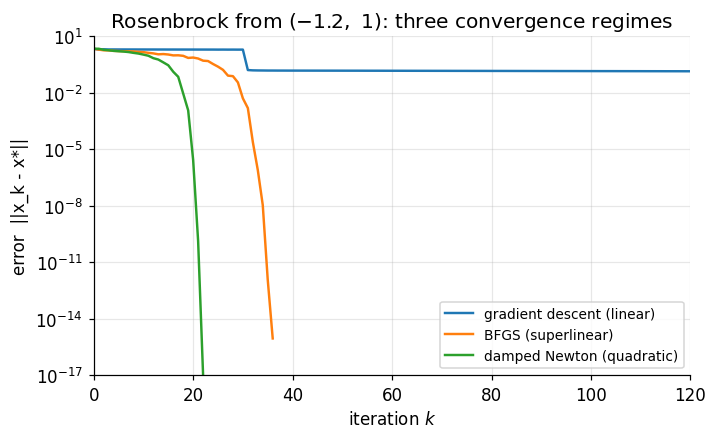

In [9]:
fig, ax = plt.subplots()
for e, style, lab in [(e_gd, "-", "gradient descent (linear)"),
                      (e_bf, "-", "BFGS (superlinear)"),
                      (e_nt, "-", "damped Newton (quadratic)")]:
    e_plot = np.maximum(e, 1e-17)
    ax.semilogy(np.arange(len(e_plot)), e_plot, style, lw=1.6, label=lab)
ax.set_xlim(0, 120)
ax.set_ylim(1e-17, 1e1)
ax.set_xlabel("iteration $k$")
ax.set_ylabel("error  ||x_k - x*||")
ax.set_title("Rosenbrock from $(-1.2,\ 1)$: three convergence regimes")
ax.legend(fontsize=9)
plt.show()

**Interpretation.** On a logarithmic error axis a linear rate is a straight line of shallow slope,
a superlinear rate bends steadily downward, and a quadratic rate falls off a cliff — the gradient
descent curve has not left the top decade by iteration 120, while BFGS and Newton have both reached
machine precision. The kink early in the Newton curve is the globalization at work: while the iterate
is outside the ball of Theorem 4.4 the line search is repeatedly cutting the step, and the quadratic
regime only begins once it is inside.

The next cell drops hypotheses on purpose. First it violates $\mathbf{s}^T\mathbf{y} \gt 0$ in
Theorem 4.7 and inspects the resulting $H_{+}$; then it drops the line search from Theorem 4.4 and runs
*pure* Newton on the strictly convex, $C^{\infty}$ function $f(x) = \sqrt{1+x^2}$ from a point outside
the guaranteed ball.

In [10]:
# (i) drop the curvature hypothesis of Theorem 4.7
s_bad, y_bad = np.array([1.0, 0.0]), np.array([-1.0, 0.0])
H_bad = bfgs_inverse(np.eye(2), s_bad, y_bad)
g_bad = np.array([1.0, 0.0])
d_bad = -H_bad @ g_bad
print(f"s.y = {s_bad @ y_bad}  (hypothesis s.y > 0 violated)")
print("H_+ =\n", H_bad, "\neigenvalues:", np.linalg.eigvalsh(H_bad))
print(f"resulting direction d = {d_bad},  grad.d = {g_bad @ d_bad:+.4f}  -> ASCENT")
assert np.min(np.linalg.eigvalsh(H_bad)) < 0 and g_bad @ d_bad > 0

# (ii) drop the line search from Theorem 4.4: f(x) = sqrt(1+x^2), x* = 0
f_s   = lambda t: np.sqrt(1.0 + t*t)
fp_s  = lambda t: t/np.sqrt(1.0 + t*t)
fpp_s = lambda t: (1.0 + t*t)**-1.5

pure, damped = [1.1], [1.1]
for _ in range(6):
    t = pure[-1]
    pure.append(t - fp_s(t)/fpp_s(t))            # closed form: t -> -t^3
for _ in range(6):
    t = damped[-1]
    d = -fp_s(t)/fpp_s(t)
    a = backtrack(f_s, t, d, fp_s(t)*d)
    damped.append(t + a*d)
print("\npure Newton   :", np.array2string(np.array(pure), precision=3))
print("damped Newton :", np.array2string(np.array(damped), precision=8))
assert abs(pure[-1]) > 1e20 and abs(damped[-1]) < 1e-12

s.y = -1.0  (hypothesis s.y > 0 violated)
H_+ =
 [[-1.  0.]
 [ 0.  1.]] 
eigenvalues: [-1.  1.]
resulting direction d = [1. 0.],  grad.d = +1.0000  -> ASCENT

pure Newton   : [ 1.100e+00 -1.331e+00  2.358e+00 -1.311e+01  2.253e+03 -1.144e+10
  1.497e+30]
damped Newton : [ 1.1       -0.1155     0.0015408 -0.         0.         0.
  0.       ]


**Interpretation.** Dropping $\mathbf{s}^T\mathbf{y} \gt 0$ produces
$H_{+} = \operatorname{diag}(-1, 1)$, an indefinite matrix whose "search direction" satisfies
$\nabla f^T\mathbf{d} = +1 \gt 0$ — an ascent direction, so the hypothesis in Theorem 4.7 is not
decoration. Dropping the line search is just as decisive: on $f(x)=\sqrt{1+x^2}$ the pure Newton map is
exactly $x \mapsto -x^3$, so from $x_0 = 1.1$ the iterates blow up like $\lvert x_0\rvert^{3^k}$ even
though $f$ is strictly convex, $C^{\infty}$ and has a perfectly nondegenerate minimizer — the failure is
that $x_0$ lies outside the ball $\lvert x\rvert \le \mu/(2M)$ of Theorem 4.4, whose radius is genuinely
finite because $f''(x) \to 0$ at infinity. Backtracking rescues the same start in one step.

The figure below plots the two runs of the previous cell on a logarithmic scale.

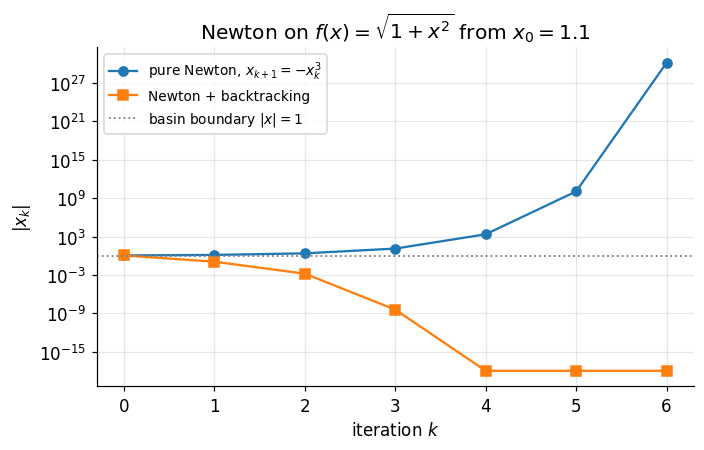

In [11]:
fig, ax = plt.subplots()
kk = np.arange(len(pure))
ax.semilogy(kk, np.abs(pure), "o-", label=r"pure Newton, $x_{k+1}=-x_k^3$")
ax.semilogy(kk, np.maximum(np.abs(damped), 1e-18), "s-", label="Newton + backtracking")
ax.axhline(1.0, color="0.5", ls=":", lw=1.2, label=r"basin boundary $|x|=1$")
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$|x_k|$")
ax.set_title(r"Newton on $f(x)=\sqrt{1+x^2}$ from $x_0=1.1$")
ax.legend(fontsize=9)
plt.show()

**Interpretation.** The two curves separate immediately and never meet: one climbs by a factor of
roughly $10^{3}$ per step, the other falls off the bottom of the axis. The dotted line at
$\lvert x\rvert = 1$ is the exact boundary of the basin of the map $x \mapsto -x^3$, and the whole role
of the line search is to move the iterate across it.

The last code cell compares hand-rolled implementations against the corresponding library routines:
the two-loop recursion against an explicitly formed dense BFGS inverse, and a hand-rolled BFGS with a
strong-Wolfe line search against `scipy.optimize.minimize(method="BFGS")`.

In [12]:
def two_loop(g, pairs, gamma):
    q, a_store = g.copy(), []
    for s, y in reversed(pairs):
        a = (s @ q)/(y @ s); a_store.append(a); q = q - a*y
    r = gamma*q
    for (s, y), a in zip(pairs, reversed(a_store)):
        b = (y @ r)/(y @ s); r = r + (a - b)*s
    return r

n_l, m_l = 6, 4
A_l = rng.standard_normal((n_l, n_l)); Q_l = A_l @ A_l.T + n_l*np.eye(n_l)
pairs = [(v, Q_l @ v) for v in rng.standard_normal((m_l, n_l))]
gamma = (pairs[-1][0] @ pairs[-1][1])/(pairs[-1][1] @ pairs[-1][1])
H_dense = gamma*np.eye(n_l)
for s, y in pairs:
    H_dense = bfgs_inverse(H_dense, s, y)
g_test = rng.standard_normal(n_l)
res_tl = np.linalg.norm(two_loop(g_test, pairs, gamma) - H_dense @ g_test)
print(f"two-loop vs dense BFGS product: residual = {res_tl:.3e}")

def my_bfgs(fun, jac, x0, iters=200, tol=1e-10):
    n = len(x0); H = np.eye(n); x = np.asarray(x0, float); g = jac(x)
    for _ in range(iters):
        d = -H @ g
        out = line_search(fun, jac, x, d, g, c1=1e-4, c2=0.9, maxiter=100)
        a = out[0]
        if a is None:
            a = backtrack(fun, x, d, g @ d); gn = jac(x + a*d)
        else:
            gn = out[5] if out[5] is not None else jac(x + a*d)
        xn = x + a*d; s, yv = xn - x, gn - g
        if s @ yv > 1e-14:
            H = bfgs_inverse(H, s, yv)
        x, g = xn, gn
        if np.linalg.norm(g) < tol:
            break
    return x

x_mine = my_bfgs(rosen, rosen_grad, np.array([-1.2, 1.0]))
res_lib = minimize(rosen, np.array([-1.2, 1.0]), jac=rosen_grad, method="BFGS",
                   options=dict(gtol=1e-10))
print(f"hand-rolled BFGS : x = {x_mine},  f = {rosen(x_mine):.3e}")
print(f"scipy BFGS       : x = {res_lib.x},  f = {res_lib.fun:.3e}")
print(f"disagreement ||x_mine - x_scipy|| = {np.linalg.norm(x_mine - res_lib.x):.3e}")
assert res_tl < 1e-12
assert np.linalg.norm(x_mine - x_star) < 1e-6
assert np.linalg.norm(x_mine - res_lib.x) < 1e-5

two-loop vs dense BFGS product: residual = 3.469e-17
hand-rolled BFGS : x = [1. 1.],  f = 3.122e-25
scipy BFGS       : x = [1. 1.],  f = 4.351e-25
disagreement ||x_mine - x_scipy|| = 2.479e-12


**Interpretation.** The two-loop recursion reproduces the dense product to $10^{-16}$, confirming that
the $O(mn)$ unrolling of Definition 3.7 is algebraically exact and not an approximation — the memory
saving costs nothing in accuracy for the pairs actually stored. The hand-rolled BFGS lands on
$(1,1)$ and agrees with SciPy's implementation to well under $10^{-5}$, which is the practical statement
that Theorems 4.6 and 4.7 plus a strong-Wolfe line search are the whole content of a production BFGS.

## 8. Applications

### Newton on a generalized linear model is iteratively reweighted least squares

For logistic regression with design matrix $X$, labels $y_i \in \{0,1\}$ and
$\pi_i = \sigma(\mathbf{x}_i^T\mathbf{w})$, the negative log-likelihood has

$$
\nabla \ell(\mathbf{w}) = X^T(\boldsymbol{\pi} - \mathbf{y}), \qquad \nabla^2 \ell(\mathbf{w}) = X^TSX, \quad S = \operatorname{diag}\left(\pi_i(1-\pi_i)\right)
$$

so the Newton system $X^TSX\,\Delta\mathbf{w} = X^T(\mathbf{y} - \boldsymbol{\pi})$ is a *weighted
least-squares problem* re-solved each iteration with updated weights. That is the IRLS algorithm inside
every classical GLM package; because $S \succ 0$ whenever no fitted probability is exactly $0$ or $1$,
$X^TSX \succ 0$ for full-column-rank $X$, and Theorem 4.4 delivers convergence in a handful of
iterations. The failure mode is also predicted by the theory: on separable data some $\pi_i \to \{0,1\}$,
$S$ becomes singular, the hypothesis $\nabla^2 f \succeq \mu I$ fails, and the iteration diverges — which is
why every GLM fitter ships a ridge penalty or a step-halving safeguard.

### Physics: equilibrium geometries and structure relaxation

Finding stable molecular geometries or elastic equilibria means minimizing an energy $E(\mathbf{q})$
over thousands to millions of coordinates. Exact Hessians of the energy are expensive, gradients
(forces) are cheap, and the secant machinery of Definition 3.6 converts a history of forces into
curvature — precisely the quasi-Newton premise. Quantum-chemistry and molecular-mechanics codes
therefore run BFGS or L-BFGS almost exclusively, and declare convergence when the largest force
component falls below a threshold, which is the first-order necessary condition of
[Module 02](../02_unconstrained_optimality_conditions/) in disguise.

### Where these methods return in deep learning

Second-order methods struggle on deep networks: the Hessian is astronomically large, minibatch noise
corrupts $\mathbf{y}_k$ so that $\mathbf{s}_k^T\mathbf{y}_k \gt 0$ can fail and Theorem 4.7 no longer
applies, and the objective is non-convex. Curvature ideas persist in modified form: K-FAC and Shampoo
approximate the Fisher or Hessian with Kronecker or block structure, and Adam
([Module 08](../08_stochastic_optimization_for_ml/)) is a diagonal curvature estimate, its element-wise
scaling $1/\sqrt{\hat{v}_k}$ playing the role of a diagonal $H_k$. Where the objective is deterministic
— physics-informed networks, style transfer, small-data fitting, calibration — full-batch L-BFGS is
still the method of choice, usually after an Adam warm start has reached the region where the secant
pairs are informative.

## 9. Key Takeaways

- If $\mathbf{d}_k$ is a descent direction and $c_1 \in (0,1)$, Armijo-acceptable steps fill an interval
  $(0,\bar{\alpha}_{\ast}]$, so backtracking terminates (Theorem 4.1).
- If additionally $\varphi$ is bounded below on the ray and $0 \lt c_1 \lt c_2 \lt 1$, the strong Wolfe
  set contains an open interval (Theorem 4.2).
- If $f$ is bounded below with $L$-Lipschitz gradient on the initial sublevel set and every step is
  Wolfe-accepted, then $\sum_k \cos^2\theta_k \lVert \nabla f_k\rVert^2 \le L(f_0-f_{\inf})/(c_1(1-c_2))$,
  so $\cos\theta_k \ge \delta \gt 0$ forces $\nabla f_k \to \mathbf{0}$ (Theorem 4.3).
- If $\nabla^2 f(\mathbf{x}^{\star}) \succeq \mu I$ and $\nabla^2 f$ is $M$-Lipschitz on the ball of radius
  $\mu/(2M)$, pure Newton contracts as $\lVert \mathbf{e}_{k+1}\rVert \le (M/\mu)\lVert \mathbf{e}_k\rVert^2$
  from any start in that ball — the constant is $M/\mu$, not $M/(2\mu)$ (Theorem 4.4).
- For any invertible $T$, pure Newton on $f(T\mathbf{y}+\mathbf{b})$ traces the same points as pure
  Newton on $f$, so no coordinate-dependent condition number can appear in a sharp Newton rate
  (Theorem 4.5).
- If $\mathbf{s}_k^T\mathbf{y}_k \gt 0$, BFGS is the *unique* symmetric matrix satisfying
  $H\mathbf{y}_k = \mathbf{s}_k$ that is closest to $H_k$ in every weighted Frobenius norm with
  $W\mathbf{s}_k = \mathbf{y}_k$; DFP is the same projection applied to $B$ (Theorem 4.6).
- If $H_k \succ 0$ and $\mathbf{s}_k^T\mathbf{y}_k \gt 0$ then $H_{k+1} \succ 0$, and a Wolfe line
  search supplies $\mathbf{s}_k^T\mathbf{y}_k \gt 0$ automatically — so BFGS directions are descent
  directions forever (Theorem 4.7).
- Under the Dennis–Moré limit, superlinear convergence needs $B_k$ to be asymptotically correct only
  along the directions actually taken, never on all of $\mathbb{R}^n$ (Theorem 4.8, cited).

## 10. References

| Result here | Canonical source |
|---|---|
| Definitions 3.2, 3.3; Theorems 4.1, 4.2 | Nocedal & Wright, *Numerical Optimization*, 2nd ed., §3.1 and Lemma 3.1; Armijo (1966); Wolfe (1969) |
| Theorem 4.3 and Proof 5.3 | Nocedal & Wright, §3.2 Theorem 3.2; Zoutendijk (1970) |
| Theorem 4.4 and Proof 5.4 | Nocedal & Wright, §3.3 Theorem 3.5; Boyd & Vandenberghe, *Convex Optimization*, §9.5.3 |
| Theorem 4.5 and Proof 5.5 | Boyd & Vandenberghe, §9.5.1 |
| Theorem 4.6 and Proof 5.6 | Nocedal & Wright, §6.1 (eq. 6.14 and the DFP dual in eq. 6.13); Dennis & Schnabel, Ch. 9 |
| Theorem 4.7 and Proof 5.7 | Nocedal & Wright, §6.1; Dennis & Schnabel, Ch. 9 Thm 9.2.1 |
| Theorem 4.8 (cited) | Nocedal & Wright, §3.3 Theorem 3.6 and §6.4 Theorem 6.6 |
| Two-loop recursion, Section 7 | Liu & Nocedal (1989); Nocedal & Wright, Algorithm 7.4 |

1. **Nocedal, J., & Wright, S. J.** (2006). *Numerical Optimization* (2nd ed.). Springer. Chapters 3, 6, 7.
2. **Boyd, S., & Vandenberghe, L.** (2004). *Convex Optimization*. Cambridge University Press. Chapter 9.
3. **Dennis, J. E., & Schnabel, R. B.** (1996). *Numerical Methods for Unconstrained Optimization and Nonlinear Equations*. SIAM Classics. Chapters 6-9.
4. **Bertsekas, D. P.** (2016). *Nonlinear Programming* (3rd ed.). Athena Scientific. Chapter 1.
5. **Liu, D. C., & Nocedal, J.** (1989). On the Limited Memory BFGS Method for Large Scale Optimization. *Mathematical Programming*, 45, 503-528.
6. **Armijo, L.** (1966). Minimization of Functions Having Lipschitz Continuous First Partial Derivatives. *Pacific Journal of Mathematics*, 16(1), 1-3.
7. **Wolfe, P.** (1969). Convergence Conditions for Ascent Methods. *SIAM Review*, 11(2), 226-235.
8. **Zoutendijk, G.** (1970). Nonlinear Programming, Computational Methods. In J. Abadie (Ed.), *Integer and Nonlinear Programming*, North-Holland, 37-86.